<a href="https://colab.research.google.com/github/Yuliana2001/Pila-Publica/blob/data_analysis/Analisis_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Inicio del Código

In [1]:
#Libreias
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.preprocessing import LabelEncoder
import seaborn as sns



In [2]:
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Reto3'  # Cambia este path según tu carpeta
file_list = os.listdir(folder_path)
dataFrames={}
print("Archivos en la carpeta:")
for file in file_list:
    file_path = os.path.join(folder_path, file)
    if file.endswith('.csv'):
        # Intentar con múltiples codificaciones
        for encoding in ['utf-8', 'ISO-8859-1','latin-1']:
            try:
                pl = pd.read_csv(file_path, encoding=encoding, sep=';')
                print(f"✅ Archivo leído: {file}")
                break  # Sale del bucle si fue exitoso
            except UnicodeDecodeError:
              pass
        else:
            print(f"⚠️ No se pudo leer csv: {file}")
            continue  # Saltar este archivo si todas las codificaciones fallan
    else:
        try:
            pl = pd.read_excel(file_path)
            print(f"✅ Archivo leído: {file}")
        except Exception as e:
            print(f"⚠️ No se pudo leer el archivo Excel: {file}")
            continue
    # Guardar el DataFrame usando el nombre del archivo como clave
    dataFrames[file] = pl





Mounted at /content/drive
Archivos en la carpeta:
✅ Archivo leído: Sesiones.csv
✅ Archivo leído: chart.csv
✅ Archivo leído: Otros errores.csv
✅ Archivo leído: Alertas.csv
✅ Archivo leído: Errores.csv
✅ Archivo leído: potencia-mxima-alcanzada.csv
✅ Archivo leído: Errores de conexion.csv
✅ Archivo leído: Transacciones.xlsx


#Valores Nulos

In [3]:
# Recorremos el diccionario de DataFrames
for nombre_archivo, dataFrame in dataFrames.items():
    nulls = dataFrame.isnull().sum()
    non_nulls = dataFrame.notnull().sum()
    dtypes = dataFrame.dtypes

    # Columnas numéricas
    min_vals = dataFrame.min(numeric_only=True)
    max_vals = dataFrame.max(numeric_only=True)
    medians = dataFrame.median(numeric_only=True)

    resumen_nulos = pd.DataFrame({
        'Columna': dataFrame.columns,
        'Valores Nulos': nulls.values,
        'Valores No Nulos': non_nulls.values,
        'Mínimo': [min_vals.get(col, '') for col in dataFrame.columns],
        'Máximo': [max_vals.get(col, '') for col in dataFrame.columns],
        'Mediana': [medians.get(col, '') for col in dataFrame.columns],
        'Tipo de Dato': [dtypes[col] for col in dataFrame.columns]

    })

    # Mostrar nombre del archivo como título
    display(HTML(f"<h3 style='color: steelblue;'>📁 Archivo: {nombre_archivo}</h3>"))

    # Mostrar DataFrame estilizado
    display(
        resumen_nulos
        .style
        .set_caption("📊 Resumen de valores por columna")
        .set_table_attributes("style='display:inline'")
        .format(na_rep='-', precision=2)
    )



,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,931,3744061.00,4971580.00,4609400.00,int64
1,Minuto a minuto,0,931,3744061.00,4971580.00,4609400.00,int64
2,Toma,0,931,1.00,2.00,1.00,int64
3,USER ID,0,931,41841.00,1298974.00,1134737.00,int64
4,Tarjeta,5,926,,,,object
5,Inicio,0,931,,,,object
6,Final,0,931,,,,object
7,Duración(mins),0,931,0.00,3951.00,135.00,int64
8,Tiempo seleccionado(mins),536,395,5.00,240.00,240.00,float64
9,Energía(kWh),0,931,0.00,55.93,10.09,float64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,Category,0,10,,,,object
1,Value,0,10,305,1818,1343.50,int64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,11,57900324.00,81636915.00,77149556.00,int64
1,Toma,0,11,,,,object
2,RFID,0,11,,,,object
3,DescripciÃ³n,0,11,,,,object
4,CÃ³digo Error,0,11,,,,object
5,Tiempo KO (min),11,0,-,-,-,float64
6,InformaciÃ³n,11,0,-,-,-,float64
7,SoluciÃ³n,11,0,-,-,-,float64
8,AutogestiÃ³n,11,0,-,-,-,float64
9,Revisado,11,0,-,-,-,float64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,66,55432131.00,85449042.00,67646983.00,int64
1,Toma,0,66,,,,object
2,RFID,0,66,,,,object
3,Descripción,0,66,,,,object
4,Código Error,0,66,,,,object
5,Tiempo KO (min),66,0,-,-,-,float64
6,Información,0,66,,,,object
7,Solución,0,66,,,,object
8,Autogestión,66,0,-,-,-,float64
9,Revisado,66,0,-,-,-,float64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,36,55451389.00,83532141.00,74728535.50,int64
1,Toma,13,23,,,,object
2,RFID,8,28,,,,object
3,Descripción,0,36,,,,object
4,Código Error,0,36,,,,object
5,Tiempo KO (min),27,9,45.00,45.00,45.00,float64
6,Información,0,36,,,,object
7,Solución,0,36,,,,object
8,Autogestión,36,0,-,-,-,float64
9,Revisado,36,0,-,-,-,float64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,DateTime,0,4790,,,,object
1,Potencia instantaneaToma 1 (kW),2323,2467,0.00,9.90,3.03,float64
2,Potencia instantanea Toma 2 (kW),2289,2501,0.00,14.72,3.60,float64


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,382,55446298.00,81501265.00,76881850.00,int64
1,RFID,34,348,,,,object
2,Descripción,0,382,,,,object
3,Código Error,0,382,,,,object
4,Tiempo KO (min),0,382,0.00,0.00,0.00,int64
5,Información,0,382,,,,object
6,Solución,0,382,,,,object
7,Autogestión,382,0,-,-,-,float64
8,Revisado,382,0,-,-,-,float64
9,Fecha,0,382,,,,object


,Columna,Valores Nulos,Valores No Nulos,Mínimo,Máximo,Mediana,Tipo de Dato
0,ID,0,882,3744061.00,4970680.00,4609693.50,int64
1,RFID,0,882,,,,object
2,Capacidad Bateria (A),7,875,13.50,76.90,45.00,float64
3,Referencia,7,875,,,,object
4,SOCKET,0,882,1.00,2.00,1.00,int64
5,ENERGY (W),0,882,1.00,55929.00,11040.50,int64
6,START SESSION,0,882,,,,object
7,CHARGING END,0,882,,,,object
8,SESSION END,0,882,,,,object
9,TIME CHARGING,0,882,0.00,3951.00,134.50,int64


#Dataframes asocioados a los Errores

In [4]:
#Errores Generales
errores=dataFrames["Errores.csv"]
otros_errores=dataFrames["Otros errores.csv"]
errores_conexion=dataFrames["Errores de conexion.csv"]

In [5]:
#Errores
errores=errores.dropna(subset=["RFID"])
errores=errores.drop(columns=['Autogestión','Revisado'])
errores['Tiempo KO (min)']=errores['Tiempo KO (min)'].fillna(0)
print(errores.info())



<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 2 to 32
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               28 non-null     int64  
 1   Toma             23 non-null     object 
 2   RFID             28 non-null     object 
 3   Descripción      28 non-null     object 
 4   Código Error     28 non-null     object 
 5   Tiempo KO (min)  28 non-null     float64
 6   Información      28 non-null     object 
 7   Solución         28 non-null     object 
 8   Fecha            28 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.2+ KB
None


In [6]:
print(errores["Código Error"].value_counts())

Código Error
33 - powermeter comm error - PowerMeterFailure    15
25 - DC leakage sensor error - OtherError          8
Connection Error                                   5
Name: count, dtype: int64


In [7]:
#Otros Errores
otros_errores=otros_errores.drop(columns=['AutogestiÃ³n','Revisado',"SoluciÃ³n","InformaciÃ³n"])
otros_errores.rename(columns={
    'DescripciÃ³n': 'Descripción',
    'CÃ³digo Error': 'Código Error',
}, inplace=True)
otros_errores['Tiempo KO (min)']=otros_errores['Tiempo KO (min)'].fillna(0)
otros_errores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               11 non-null     int64  
 1   Toma             11 non-null     object 
 2   RFID             11 non-null     object 
 3   Descripción      11 non-null     object 
 4   Código Error     11 non-null     object 
 5   Tiempo KO (min)  11 non-null     float64
 6   Fecha            11 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 748.0+ bytes


In [8]:
print(otros_errores["Código Error"].value_counts())

Código Error
17 - ac failure - UnderVoltage    9
#¿NOMBRE?                         2
Name: count, dtype: int64


In [9]:
#Errores de Conexion
errores_conexion=errores_conexion.drop(columns=['Autogestión','Revisado'])
errores_conexion=errores_conexion.dropna(subset=["RFID"])
errores_conexion.info()


<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 347
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               348 non-null    int64 
 1   RFID             348 non-null    object
 2   Descripción      348 non-null    object
 3   Código Error     348 non-null    object
 4   Tiempo KO (min)  348 non-null    int64 
 5   Información      348 non-null    object
 6   Solución         348 non-null    object
 7   Fecha            348 non-null    object
dtypes: int64(2), object(6)
memory usage: 24.5+ KB


In [10]:
print(errores_conexion["Código Error"].value_counts())

Código Error
Connection Error    348
Name: count, dtype: int64


In [11]:
errores_totales=pd.concat([errores,otros_errores,errores_conexion])
errores_totales["Solución"]=errores_totales["Solución"].fillna("Nosabe")
errores_totales["Información"]=errores_totales["Información"].fillna("Nosabe")
errores_totales["Toma"]=errores_totales["Toma"].fillna("Nosabe")
errores_totales['Fecha'] = pd.to_datetime(errores_totales['Fecha'], format='%d-%m-%Y, %H:%M', errors='coerce')
errores_totales['DATE'] = errores_totales['Fecha'].dt.date
errores_totales['HOUR'] = errores_totales['Fecha'].dt.time
errores_totales=errores_totales.drop(columns=['Fecha'])
errores_totales.info()
errores_totales.to_csv('errores_generales.csv', index=False)
errores_totales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 387 entries, 2 to 347
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               387 non-null    int64  
 1   Toma             387 non-null    object 
 2   RFID             387 non-null    object 
 3   Descripción      387 non-null    object 
 4   Código Error     387 non-null    object 
 5   Tiempo KO (min)  387 non-null    float64
 6   Información      387 non-null    object 
 7   Solución         387 non-null    object 
 8   DATE             387 non-null    object 
 9   HOUR             387 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 33.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 387 entries, 2 to 347
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               387 non-null    int64  
 1   Toma             387 non-null    object 
 

## EDA Errores

In [12]:
#Errores que hay en total
errores_generales=pd.read_csv("errores_generales.csv")
errores_generales.loc[errores_generales['Código Error'] == '#¿NOMBRE?', 'Código Error'] = '17 - ac failure - UnderVoltage'
print(errores_generales["Código Error"].value_counts())


Código Error
Connection Error                                  353
33 - powermeter comm error - PowerMeterFailure     15
17 - ac failure - UnderVoltage                     11
25 - DC leakage sensor error - OtherError           8
Name: count, dtype: int64


In [13]:
errores_generales.head()

,ID,Toma,RFID,Descripción,Código Error,Tiempo KO (min),Información,Solución,DATE,HOUR
0,83043413,1,7B0734A0,25 - DC leakage sensor error - Charger Status:...,25 - DC leakage sensor error - OtherError,0.0,El sensor de fuga de DC está funcionando mal,Llama a la asistencia técnica,2025-04-03,13:04:00
1,82937420,2,1BF4C9EC,25 - DC leakage sensor error - Charger Status:...,25 - DC leakage sensor error - OtherError,0.0,El sensor de fuga de DC está funcionando mal,Llama a la asistencia técnica,2025-04-02,10:00:00
2,81994899,1,D45E7EAF,25 - DC leakage sensor error - Charger Status:...,25 - DC leakage sensor error - OtherError,0.0,El sensor de fuga de DC está funcionando mal,Llama a la asistencia técnica,2025-03-19,11:16:00
3,81636903,1 2,4210747D 9E4D5697,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2025-03-13,13:01:00
4,79874209,1,C8FCAD98,25 - DC leakage sensor error - Charger Status:...,25 - DC leakage sensor error - OtherError,0.0,El sensor de fuga de DC está funcionando mal,Llama a la asistencia técnica,2025-02-22,07:02:00


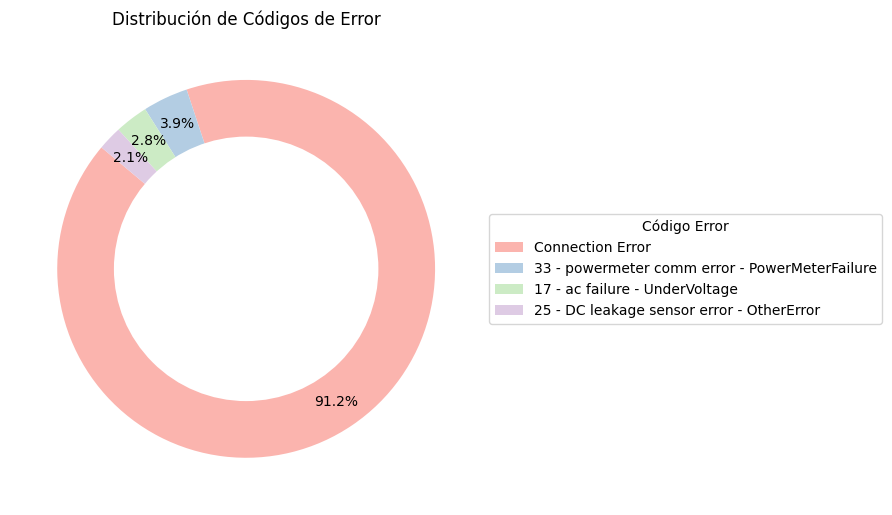

In [14]:
# Contar errores
conteo_errores = errores_generales["Código Error"].value_counts()

# Colores pastel suaves
colors = plt.cm.Pastel1.colors

# Crear gráfico de pastel
plt.figure(figsize=(9, 9))
patches, texts, autotexts = plt.pie(
    conteo_errores.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85
)

# Dibujar círculo blanco al centro para efecto de donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Agregar leyenda
plt.legend(patches, conteo_errores.index, title="Código Error", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Distribución de Códigos de Error")
plt.tight_layout()
plt.show()





In [15]:
#DataFrames de Errores por mes
errores_generales['DATE'] = pd.to_datetime(errores_generales['DATE'])
# Crear una nueva columna con el año y mes en formato AAAA-MM
errores_generales['MES'] = errores_generales['DATE'].dt.to_period('M')
# Crear una lista vacía para almacenar los DataFrames
lista_dataframes = []
# Agrupar por mes
for mes, grupo in errores_generales.groupby('MES'):
    conteo = grupo['Código Error'].value_counts().reset_index()
    conteo.columns = ['Código Error', 'conteo']
    conteo['MES'] = mes
    lista_dataframes.append((mes, conteo))

for mes, df_mes in lista_dataframes:
    display(HTML(f"<h3>Mes: {mes}</h3>"))
    display(HTML(df_mes.to_html(index=False)))



Código Error,conteo,MES
25 - DC leakage sensor error - OtherError,1,2024-07


Código Error,conteo,MES
17 - ac failure - UnderVoltage,2,2024-08
33 - powermeter comm error - PowerMeterFailure,1,2024-08


Código Error,conteo,MES
33 - powermeter comm error - PowerMeterFailure,3,2024-09


Código Error,conteo,MES
33 - powermeter comm error - PowerMeterFailure,2,2024-10
Connection Error,1,2024-10


Código Error,conteo,MES
Connection Error,2,2024-11


Código Error,conteo,MES
Connection Error,77,2024-12
25 - DC leakage sensor error - OtherError,1,2024-12
33 - powermeter comm error - PowerMeterFailure,1,2024-12
17 - ac failure - UnderVoltage,1,2024-12


Código Error,conteo,MES
Connection Error,52,2025-01
33 - powermeter comm error - PowerMeterFailure,3,2025-01
25 - DC leakage sensor error - OtherError,2,2025-01
17 - ac failure - UnderVoltage,2,2025-01


Código Error,conteo,MES
Connection Error,220,2025-02
33 - powermeter comm error - PowerMeterFailure,4,2025-02
17 - ac failure - UnderVoltage,4,2025-02
25 - DC leakage sensor error - OtherError,1,2025-02


Código Error,conteo,MES
17 - ac failure - UnderVoltage,2,2025-03
25 - DC leakage sensor error - OtherError,1,2025-03
33 - powermeter comm error - PowerMeterFailure,1,2025-03
Connection Error,1,2025-03


Código Error,conteo,MES
25 - DC leakage sensor error - OtherError,2,2025-04


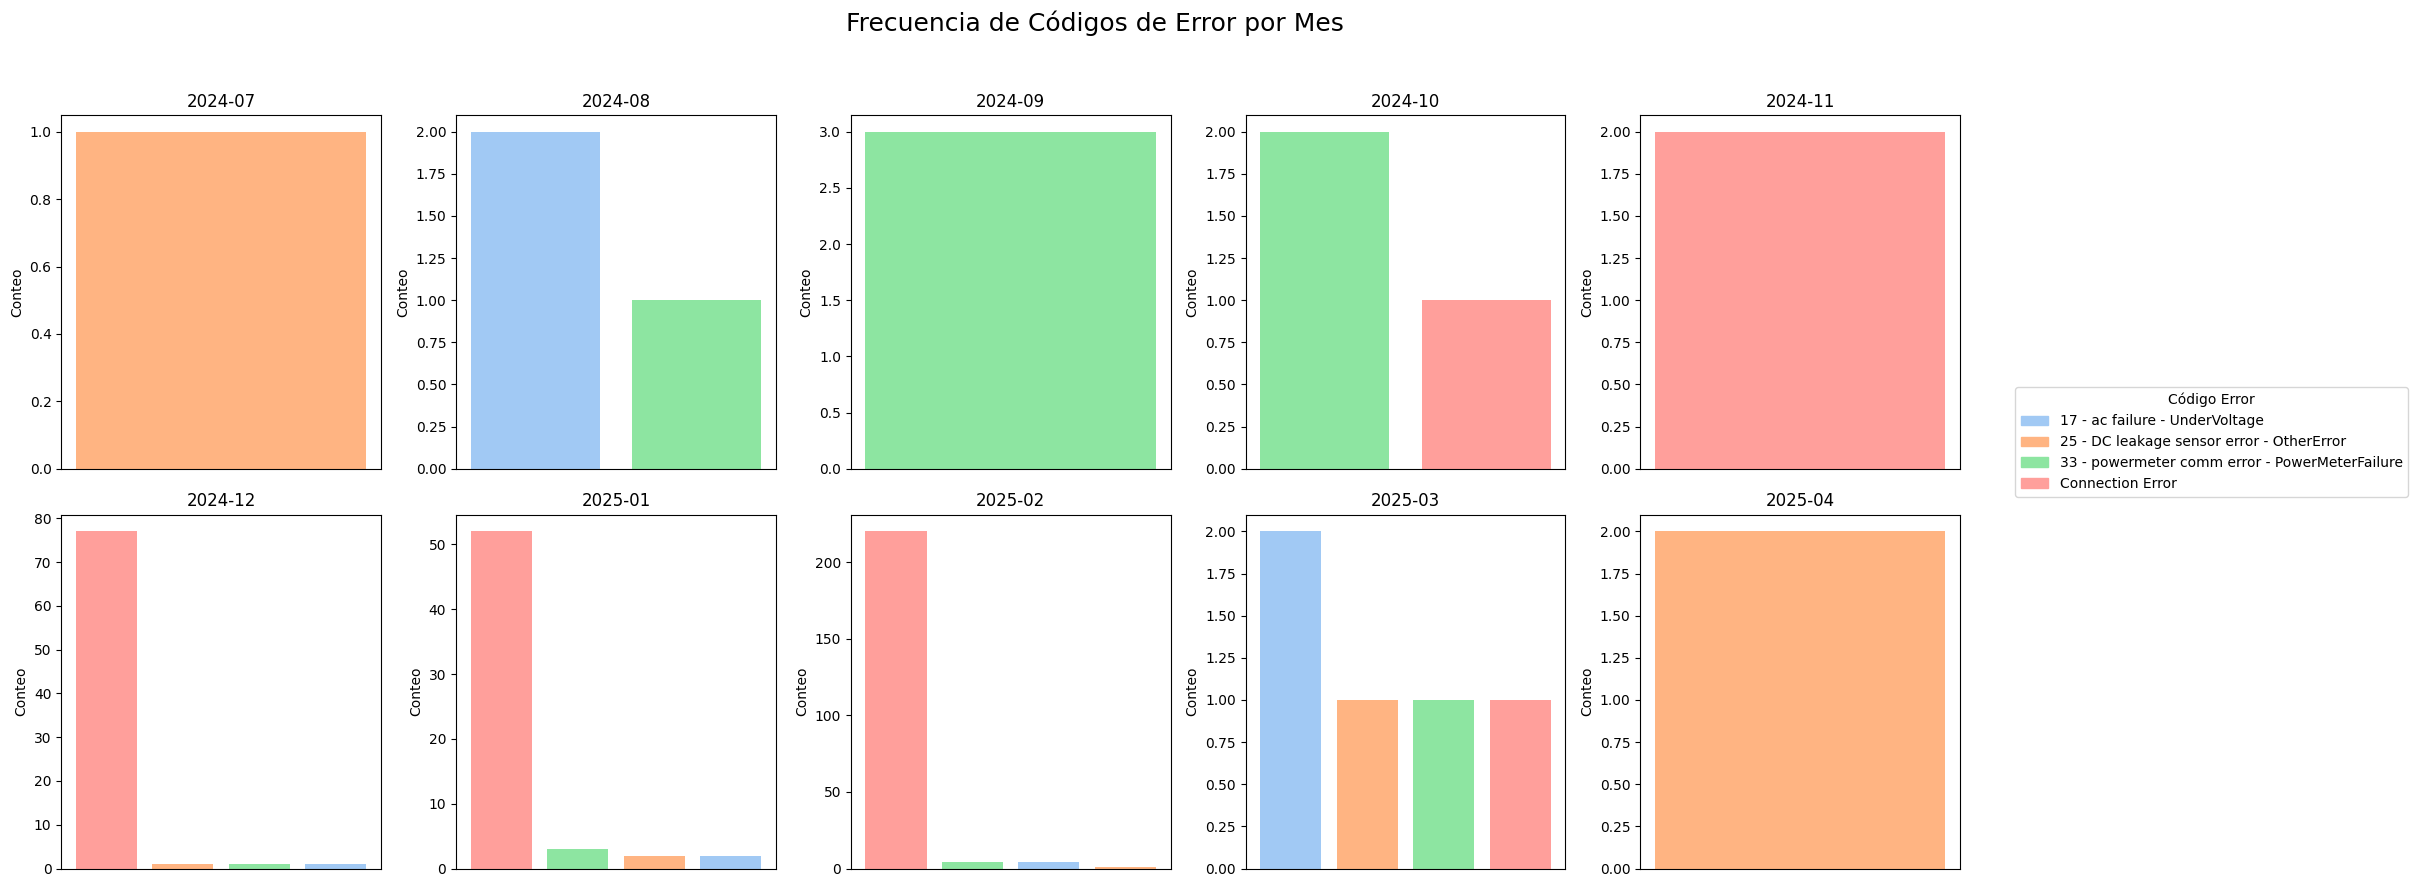

In [16]:
#Graficos Por Mes
# Crear colores consistentes para cada código de error
todos_codigos = sorted(set(c for _, df in lista_dataframes for c in df['Código Error']))
palette = sns.color_palette('pastel', len(todos_codigos))
colores_por_codigo = dict(zip(todos_codigos, palette))

# Crear subplots
total = len(lista_dataframes)
filas, columnas = 2, 5
fig, axs = plt.subplots(filas, columnas, figsize=(22, 9))
fig.suptitle('Frecuencia de Códigos de Error por Mes', fontsize=18)
axs = axs.flatten()

# Dibujar los gráficos
for i, (mes, df_mes) in enumerate(lista_dataframes):
    ax = axs[i]
    colores = [colores_por_codigo[cod] for cod in df_mes['Código Error']]
    bars = ax.bar(range(len(df_mes)), df_mes['conteo'], color=colores)
    ax.set_title(str(mes))
    ax.set_xticks([])  # Sin nombres de códigos en X
    ax.set_xlabel('')
    ax.set_ylabel('Conteo')

# Leyenda general
handles = [plt.Rectangle((0,0),1,1, color=colores_por_codigo[c]) for c in todos_codigos]
labels = [str(c) for c in todos_codigos]
fig.legend(handles, labels, title='Código Error', loc='center right', bbox_to_anchor=(1.1, 0.5))

# Eliminar subplots vacíos
for j in range(i + 1, filas * columnas):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
errores_generales=errores_generales.drop(columns=['MES'])

#Dataframe Alertas

In [17]:
#Alertas
Alertas=dataFrames["Alertas.csv"]
Alertas=Alertas.drop(columns=['Autogestión','Revisado'])
Alertas['Tiempo KO (min)']=Alertas['Tiempo KO (min)'].fillna(0)
Alertas['Fecha'] = pd.to_datetime(Alertas['Fecha'], format='%d-%m-%Y, %H:%M', errors='coerce')
Alertas['DATE'] = Alertas['Fecha'].dt.date
Alertas['HOUR'] = Alertas['Fecha'].dt.time
Alertas=Alertas.drop(columns=['Fecha'])
Alertas.info()
Alertas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               66 non-null     int64  
 1   Toma             66 non-null     object 
 2   RFID             66 non-null     object 
 3   Descripción      66 non-null     object 
 4   Código Error     66 non-null     object 
 5   Tiempo KO (min)  66 non-null     float64
 6   Información      66 non-null     object 
 7   Solución         66 non-null     object 
 8   DATE             66 non-null     object 
 9   HOUR             66 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 5.3+ KB


,ID,Toma,RFID,Descripción,Código Error,Tiempo KO (min),Información,Solución,DATE,HOUR
0,85449042,1,9D45BEFB,15 - control pilot shortcircuit - Charger Stat...,15 - control pilot shortcircuit - OtherError,0.0,Hay un cortocircuito en el piloto de control,Desconecte el conector y vuelva a conectarlo. ...,2025-04-29,11:56:00
1,84954172,2,62AAF420,16 - control pilot no diode - Charger Status: ...,16 - control pilot no diode - OtherError,0.0,Piloto de control de EV no tiene el diodo,Code 16,2025-04-24,17:39:00
2,83378957,2,D45E7EAF,35 - DC leakage error - Charger Status: Faulted,35 - DC leakage error - OtherError,0.0,Hay una fuga de corriente contínua,Este problema desaparecerá cuando la sesión te...,2025-04-07,08:58:00
3,81638873,1 2,4210747D ADB2C99C,11 - open door - Charger Status: Faulted,11 - open door - OtherError,0.0,La puerta está abierta,Cierre la puerta,2025-03-13,13:45:00
4,81637519,1 2,4210747D 9E4D5697,11 - open door - Charger Status: Faulted,11 - open door - OtherError,0.0,La puerta está abierta,Cierre la puerta,2025-03-13,13:14:00


In [18]:
print(Alertas["Código Error"].value_counts())
print("\n")
print(errores_generales["Código Error"].value_counts())

Código Error
15 - control pilot shortcircuit - OtherError    26
11 - open door - OtherError                     23
16 - control pilot no diode - OtherError        13
35 - DC leakage error - OtherError               4
Name: count, dtype: int64


Código Error
Connection Error                                  353
33 - powermeter comm error - PowerMeterFailure     15
17 - ac failure - UnderVoltage                     11
25 - DC leakage sensor error - OtherError           8
Name: count, dtype: int64


In [72]:
errores_generales_Alertas=pd.concat([errores_generales,Alertas])
errores_generales_Alertas.info()
print("\n")
print(errores_generales_Alertas["Código Error"].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 453 entries, 0 to 65
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               453 non-null    int64  
 1   Toma             453 non-null    object 
 2   RFID             453 non-null    object 
 3   Descripción      453 non-null    object 
 4   Código Error     453 non-null    object 
 5   Tiempo KO (min)  453 non-null    float64
 6   Información      453 non-null    object 
 7   Solución         453 non-null    object 
 8   DATE             453 non-null    object 
 9   HOUR             453 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 38.9+ KB


Código Error
Connection Error                                  353
15 - control pilot shortcircuit - OtherError       26
11 - open door - OtherError                        23
33 - powermeter comm error - PowerMeterFailure     15
16 - control pilot no diode - OtherError           13
1

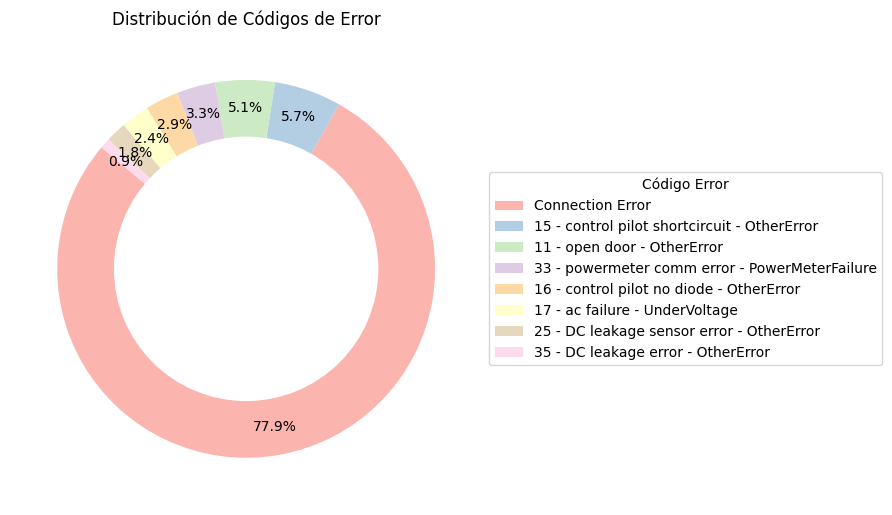

In [73]:
# Contar errores
conteo_errores = errores_generales_Alertas["Código Error"].value_counts()

# Colores pastel suaves
colors = plt.cm.Pastel1.colors

# Crear gráfico de pastel
plt.figure(figsize=(9, 9))
patches, texts, autotexts = plt.pie(
    conteo_errores.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85
)

# Dibujar círculo blanco al centro para efecto de donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Agregar leyenda
plt.legend(patches, conteo_errores.index, title="Código Error", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Distribución de Códigos de Error")
plt.tight_layout()
plt.show()

In [74]:
#DataFrames de Errores por mes
errores_generales_Alertas['DATE'] = pd.to_datetime(errores_generales_Alertas['DATE'])
# Crear una nueva columna con el año y mes en formato AAAA-MM
errores_generales_Alertas['MES'] = errores_generales_Alertas['DATE'].dt.to_period('M')
# Crear una lista vacía para almacenar los DataFrames
lista_dataframes = []
# Agrupar por mes
for mes, grupo in errores_generales_Alertas.groupby('MES'):
    conteo = grupo['Código Error'].value_counts().reset_index()
    conteo.columns = ['Código Error', 'conteo']
    conteo['MES'] = mes
    lista_dataframes.append((mes, conteo))

for mes, df_mes in lista_dataframes:
    display(HTML(f"<h3>Mes: {mes}</h3>"))
    display(HTML(df_mes.to_html(index=False)))

Código Error,conteo,MES
15 - control pilot shortcircuit - OtherError,6,2024-07
11 - open door - OtherError,2,2024-07
16 - control pilot no diode - OtherError,2,2024-07
25 - DC leakage sensor error - OtherError,1,2024-07


Código Error,conteo,MES
15 - control pilot shortcircuit - OtherError,5,2024-08
17 - ac failure - UnderVoltage,2,2024-08
33 - powermeter comm error - PowerMeterFailure,1,2024-08
16 - control pilot no diode - OtherError,1,2024-08
11 - open door - OtherError,1,2024-08


Código Error,conteo,MES
15 - control pilot shortcircuit - OtherError,4,2024-09
11 - open door - OtherError,4,2024-09
33 - powermeter comm error - PowerMeterFailure,3,2024-09
16 - control pilot no diode - OtherError,1,2024-09


Código Error,conteo,MES
33 - powermeter comm error - PowerMeterFailure,2,2024-10
11 - open door - OtherError,2,2024-10
35 - DC leakage error - OtherError,2,2024-10
Connection Error,1,2024-10
15 - control pilot shortcircuit - OtherError,1,2024-10
16 - control pilot no diode - OtherError,1,2024-10


Código Error,conteo,MES
Connection Error,2,2024-11
15 - control pilot shortcircuit - OtherError,1,2024-11
16 - control pilot no diode - OtherError,1,2024-11
11 - open door - OtherError,1,2024-11


Código Error,conteo,MES
Connection Error,77,2024-12
11 - open door - OtherError,2,2024-12
16 - control pilot no diode - OtherError,2,2024-12
33 - powermeter comm error - PowerMeterFailure,1,2024-12
25 - DC leakage sensor error - OtherError,1,2024-12
17 - ac failure - UnderVoltage,1,2024-12
15 - control pilot shortcircuit - OtherError,1,2024-12


Código Error,conteo,MES
Connection Error,52,2025-01
33 - powermeter comm error - PowerMeterFailure,3,2025-01
25 - DC leakage sensor error - OtherError,2,2025-01
17 - ac failure - UnderVoltage,2,2025-01
11 - open door - OtherError,2,2025-01
15 - control pilot shortcircuit - OtherError,2,2025-01
16 - control pilot no diode - OtherError,2,2025-01
35 - DC leakage error - OtherError,1,2025-01


Código Error,conteo,MES
Connection Error,220,2025-02
11 - open door - OtherError,5,2025-02
33 - powermeter comm error - PowerMeterFailure,4,2025-02
17 - ac failure - UnderVoltage,4,2025-02
15 - control pilot shortcircuit - OtherError,2,2025-02
16 - control pilot no diode - OtherError,2,2025-02
25 - DC leakage sensor error - OtherError,1,2025-02


Código Error,conteo,MES
11 - open door - OtherError,4,2025-03
15 - control pilot shortcircuit - OtherError,3,2025-03
17 - ac failure - UnderVoltage,2,2025-03
25 - DC leakage sensor error - OtherError,1,2025-03
33 - powermeter comm error - PowerMeterFailure,1,2025-03
Connection Error,1,2025-03


Código Error,conteo,MES
25 - DC leakage sensor error - OtherError,2,2025-04
15 - control pilot shortcircuit - OtherError,1,2025-04
16 - control pilot no diode - OtherError,1,2025-04
35 - DC leakage error - OtherError,1,2025-04


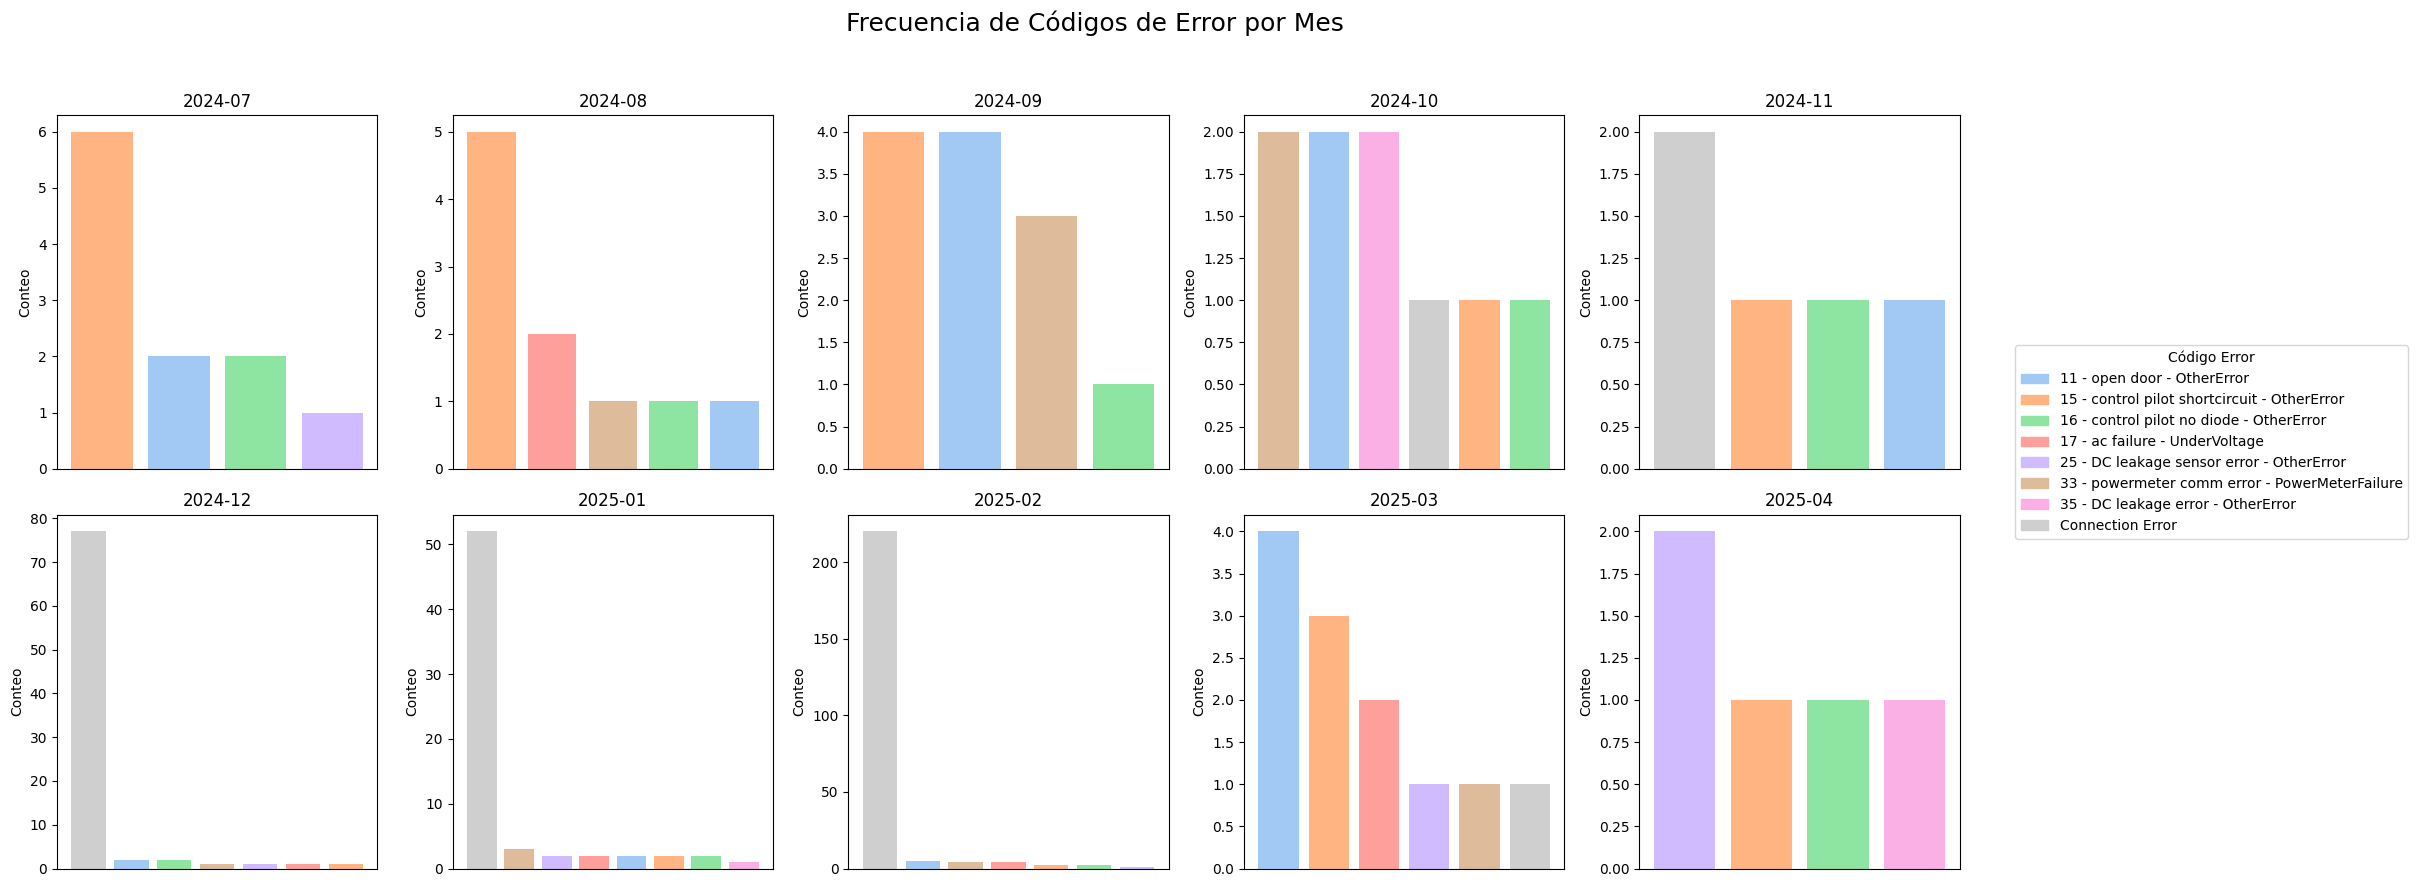

In [75]:
#Graficos Por Mes
# Crear colores consistentes para cada código de error
todos_codigos = sorted(set(c for _, df in lista_dataframes for c in df['Código Error']))
palette = sns.color_palette('pastel', len(todos_codigos))
colores_por_codigo = dict(zip(todos_codigos, palette))

# Crear subplots
total = len(lista_dataframes)
filas, columnas = 2, 5
fig, axs = plt.subplots(filas, columnas, figsize=(22, 9))
fig.suptitle('Frecuencia de Códigos de Error por Mes', fontsize=18)
axs = axs.flatten()

# Dibujar los gráficos
for i, (mes, df_mes) in enumerate(lista_dataframes):
    ax = axs[i]
    colores = [colores_por_codigo[cod] for cod in df_mes['Código Error']]
    bars = ax.bar(range(len(df_mes)), df_mes['conteo'], color=colores)
    ax.set_title(str(mes))
    ax.set_xticks([])  # Sin nombres de códigos en X
    ax.set_xlabel('')
    ax.set_ylabel('Conteo')

# Leyenda general
handles = [plt.Rectangle((0,0),1,1, color=colores_por_codigo[c]) for c in todos_codigos]
labels = [str(c) for c in todos_codigos]
fig.legend(handles, labels, title='Código Error', loc='center right', bbox_to_anchor=(1.1, 0.5))

# Eliminar subplots vacíos
for j in range(i + 1, filas * columnas):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
errores_generales_Alertas=errores_generales_Alertas.drop(columns=['MES'])

In [76]:
# Agrupar por día y código de error para obtener la frecuencia
errores_por_dia = errores_generales_Alertas.groupby([
    errores_generales_Alertas['DATE'].dt.date, 'Código Error'
]).size().reset_index(name='frecuencia')

# Convertir DATE a datetime y agregar columna MES
errores_por_dia['DATE'] = pd.to_datetime(errores_por_dia['DATE'])
errores_por_dia['MES'] = errores_por_dia['DATE'].dt.to_period('M')

# Obtener los meses únicos ordenados
lista_meses = sorted(errores_por_dia['MES'].unique())

# Crear diccionario para almacenar los DataFrames por mes
dataframes_por_mes = {}

# Generar un DataFrame por cada mes con errores como columnas y fechas como índice
for mes in lista_meses:
    df_mes = errores_por_dia[errores_por_dia['MES'] == mes]
    pivot = df_mes.pivot_table(index='DATE', columns='Código Error', values='frecuencia', fill_value=0)
    dataframes_por_mes[str(mes)] = pivot
for mes, df in dataframes_por_mes.items():
    titulo_html = f"""
    <h2 style="color: #2C3E50; background-color: #ECF0F1;
               padding: 10px; border-radius: 8px;
               border-left: 6px solid #3498DB;">
        Frecuencia diaria de errores para {mes}
    </h2>
    """
    display(HTML(titulo_html))
    display(df.style.background_gradient(cmap='Blues', axis=0).format("{:.0f}"))

Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,25 - DC leakage sensor error - OtherError
DATE,,,,
2024-07-03 00:00:00,0,5,1,0
2024-07-16 00:00:00,0,1,1,0
2024-07-17 00:00:00,2,0,0,0
2024-07-25 00:00:00,0,0,0,1


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,17 - ac failure - UnderVoltage,33 - powermeter comm error - PowerMeterFailure
DATE,,,,,
2024-08-05 00:00:00,1,0,0,2,1
2024-08-13 00:00:00,0,2,1,0,0
2024-08-14 00:00:00,0,1,0,0,0
2024-08-21 00:00:00,0,2,0,0,0


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,33 - powermeter comm error - PowerMeterFailure
DATE,,,,
2024-09-02 00:00:00,0,2,1,0
2024-09-05 00:00:00,4,0,0,1
2024-09-20 00:00:00,0,1,0,0
2024-09-26 00:00:00,0,1,0,0
2024-09-27 00:00:00,0,0,0,2


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,33 - powermeter comm error - PowerMeterFailure,35 - DC leakage error - OtherError,Connection Error
DATE,,,,,,
2024-10-03 00:00:00,0,0,0,2,0,0
2024-10-08 00:00:00,1,0,0,0,0,0
2024-10-11 00:00:00,0,0,0,0,1,0
2024-10-18 00:00:00,1,0,0,0,0,0
2024-10-22 00:00:00,0,0,0,0,1,0
2024-10-23 00:00:00,0,1,0,0,0,0
2024-10-25 00:00:00,0,0,1,0,0,0
2024-10-30 00:00:00,0,0,0,0,0,1


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,Connection Error
DATE,,,,
2024-11-14 00:00:00,1,0,0,0
2024-11-15 00:00:00,0,0,1,1
2024-11-18 00:00:00,0,1,0,0
2024-11-27 00:00:00,0,0,0,1


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,17 - ac failure - UnderVoltage,25 - DC leakage sensor error - OtherError,33 - powermeter comm error - PowerMeterFailure,Connection Error
DATE,,,,,,,
2024-12-04 00:00:00,0,0,0,0,0,0,32
2024-12-05 00:00:00,1,0,0,1,0,1,28
2024-12-11 00:00:00,0,0,0,0,0,0,14
2024-12-12 00:00:00,0,0,0,0,0,0,3
2024-12-16 00:00:00,1,1,1,0,1,0,0
2024-12-19 00:00:00,0,0,1,0,0,0,0


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,17 - ac failure - UnderVoltage,25 - DC leakage sensor error - OtherError,33 - powermeter comm error - PowerMeterFailure,35 - DC leakage error - OtherError,Connection Error
DATE,,,,,,,,
2025-01-03 00:00:00,0,1,2,0,0,0,0,0
2025-01-07 00:00:00,0,0,0,0,0,0,1,0
2025-01-15 00:00:00,1,0,0,1,0,1,0,16
2025-01-16 00:00:00,0,1,0,0,0,0,0,0
2025-01-27 00:00:00,0,0,0,0,1,1,0,6
2025-01-28 00:00:00,0,0,0,0,1,0,0,0
2025-01-30 00:00:00,1,0,0,0,0,0,0,0
2025-01-31 00:00:00,0,0,0,1,0,1,0,30


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,17 - ac failure - UnderVoltage,25 - DC leakage sensor error - OtherError,33 - powermeter comm error - PowerMeterFailure,Connection Error
DATE,,,,,,,
2025-02-01 00:00:00,0,0,0,0,0,0,95
2025-02-02 00:00:00,0,0,0,0,0,0,95
2025-02-03 00:00:00,1,0,0,1,0,1,26
2025-02-04 00:00:00,2,0,0,3,0,3,3
2025-02-05 00:00:00,0,0,2,0,0,0,0
2025-02-06 00:00:00,2,0,0,0,0,0,0
2025-02-12 00:00:00,0,1,0,0,0,0,0
2025-02-22 00:00:00,0,0,0,0,1,0,0
2025-02-23 00:00:00,0,0,0,0,0,0,1


Código Error,11 - open door - OtherError,15 - control pilot shortcircuit - OtherError,17 - ac failure - UnderVoltage,25 - DC leakage sensor error - OtherError,33 - powermeter comm error - PowerMeterFailure,Connection Error
DATE,,,,,,
2025-03-01 00:00:00,0,1,0,0,0,0
2025-03-07 00:00:00,0,1,0,0,0,0
2025-03-11 00:00:00,0,1,0,0,0,0
2025-03-12 00:00:00,0,0,0,0,0,1
2025-03-13 00:00:00,4,0,2,0,1,0
2025-03-19 00:00:00,0,0,0,1,0,0


Código Error,15 - control pilot shortcircuit - OtherError,16 - control pilot no diode - OtherError,25 - DC leakage sensor error - OtherError,35 - DC leakage error - OtherError
DATE,,,,
2025-04-02 00:00:00,0,0,1,0
2025-04-03 00:00:00,0,0,1,0
2025-04-07 00:00:00,0,0,0,1
2025-04-24 00:00:00,0,1,0,0
2025-04-29 00:00:00,1,0,0,0


In [77]:
print(errores_generales_Alertas["Toma"].value_counts())
errores_generales_Alertas['Toma'] = errores_generales_Alertas['Toma'].str.replace(r'\s+', ' ', regex=True).str.strip()
# Separar y explotar en filas
errores_generales_Alertas = errores_generales_Alertas.assign(Toma=errores_generales_Alertas['Toma'].str.split(' ')).explode('Toma').reset_index(drop=True)
errores_generales_Alertas.to_csv('errores_generales_Alertas.csv', index=False)

Toma
Nosabe                 353
1                 2     46
1                       28
2                       26
Name: count, dtype: int64


In [25]:
print(errores_generales_Alertas["Toma"].value_counts())

Toma
Nosabe    353
1          74
2          72
Name: count, dtype: int64


In [26]:
print(errores_generales_Alertas["RFID"].value_counts())

RFID
7B0734A0                                         246
B46415CD                                          80
D7A39F47                                          17
D45E7EAF                 9D45BEFB                 16
52FC1964                 4210747D                 16
E2541124                                          14
4210747D                 9E4D5697                 12
A2D6FE57                                          10
7B0734A0                 17E7BA2C                  8
4210747D                                           6
D45E7EAF                                           6
81407EED                 8063448D                  6
D7A39F47                 8063448D                  6
62AAF420                                           5
E2541124                 4210747D                  4
963F779B                                           4
81407EED                 D6FF153E                  4
1BF4C9EC                                           3
9D45BEFB                                 

In [78]:
errores=pd.read_csv("errores_generales_Alertas.csv")
print(errores["Código Error"].value_counts())

Código Error
Connection Error                                  353
11 - open door - OtherError                        45
33 - powermeter comm error - PowerMeterFailure     28
15 - control pilot shortcircuit - OtherError       26
17 - ac failure - UnderVoltage                     22
16 - control pilot no diode - OtherError           13
25 - DC leakage sensor error - OtherError           8
35 - DC leakage error - OtherError                  4
Name: count, dtype: int64


In [81]:
errores[errores["Código Error"]=="Connection Error"].head(10)

,ID,Toma,RFID,Descripción,Código Error,Tiempo KO (min),Información,Solución,DATE,HOUR
14,76803342,Nosabe,7B0734A0,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-31,17:35:00
20,76237326,Nosabe,A2D6FE57,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-27,15:20:00
24,74719932,Nosabe,D7A39F47,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-15,08:26:00
26,70572794,Nosabe,B46415CD,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2024-12-11,18:32:00
29,69602120,Nosabe,B46415CD,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2024-12-04,17:01:00
63,81501265,Nosabe,4210747D,Charger without communication,Connection Error,0.0,El cargador no inició la conexión por websocket,Vuelva a comprobarlo en 15 minutos,2025-03-12,01:21:00
64,79991383,Nosabe,B46415CD,Charger without communication,Connection Error,0.0,El cargador no inició la conexión por websocket,Vuelva a comprobarlo en 15 minutos,2025-02-23,11:02:00
65,77305423,Nosabe,11D843BE,Charger without communication,Connection Error,0.0,El cargador no inició la conexión por websocket,Vuelva a comprobarlo en 15 minutos,2025-02-04,09:02:00
66,77304116,Nosabe,11D843BE,Charger without communication,Connection Error,0.0,El cargador no inició la conexión por websocket,Vuelva a comprobarlo en 15 minutos,2025-02-04,08:51:00
67,77302757,Nosabe,9D45BEFB,Charger without communication,Connection Error,0.0,El cargador no inició la conexión por websocket,Vuelva a comprobarlo en 15 minutos,2025-02-04,08:37:00


In [89]:
errores['DATE'] = pd.to_datetime(errores['DATE'])

# Ordenar el DataFrame por la columna 'DATE' en orden ascendente
errores = errores.sort_values(by='DATE', ascending=True)
errores[(errores["Código Error"]=="Connection Error") & (errores["Tiempo KO (min)"]>0.0)].head(10)

,ID,Toma,RFID,Descripción,Código Error,Tiempo KO (min),Información,Solución,DATE,HOUR
29,69602120,Nosabe,B46415CD,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2024-12-04,17:01:00
26,70572794,Nosabe,B46415CD,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2024-12-11,18:32:00
24,74719932,Nosabe,D7A39F47,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-15,08:26:00
20,76237326,Nosabe,A2D6FE57,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-27,15:20:00
14,76803342,Nosabe,7B0734A0,Charger without communication,Connection Error,45.0,El cargador está sin conexión desde hace más d...,Enviando email al administrador,2025-01-31,17:35:00


In [90]:
errores[errores["Código Error"]=="33 - powermeter comm error - PowerMeterFailure"].head(10)

,ID,Toma,RFID,Descripción,Código Error,Tiempo KO (min),Información,Solución,DATE,HOUR
39,57900573,2,52FC1964 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-08-05,14:20:00
38,57900573,1,52FC1964 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-08-05,14:20:00
36,60603893,1,52FC1964 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-05,13:57:00
37,60603893,2,52FC1964 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-05,13:57:00
35,62762330,2,0471488A317780 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-27,10:00:00
34,62762330,1,0471488A317780 4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-27,10:00:00
33,62778534,2,04611652CA5E80 963F779B,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-27,14:38:00
32,62778534,1,04611652CA5E80 963F779B,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-09-27,14:38:00
31,63321203,2,4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-10-03,18:39:00
30,63322127,2,4210747D,33 - powermeter comm error - Charger Status: F...,33 - powermeter comm error - PowerMeterFailure,0.0,Error de comunicación del medidor de potencia,Verifique la comunicación del medidor de poten...,2024-10-03,18:53:00


In [92]:
# Filtrar solo los registros con 'Connection Error'
connection_errors = errores[errores['Código Error'] == 'Connection Error']

# Agrupar por fecha y contar cuántos hay por día
Serie_Errores = connection_errors.groupby(connection_errors['DATE'].dt.date).size().reset_index(name='Conexion error count')

# Renombrar columna de fecha
Serie_Errores.columns = ['DIA', 'Conexion error count']

# Mostrar el resultado
display(Serie_Errores)


,DIA,Conexion error count
0,2024-10-30,1
1,2024-11-15,1
2,2024-11-27,1
3,2024-12-04,32
4,2024-12-05,28
5,2024-12-11,14
6,2024-12-12,3
7,2025-01-15,16
8,2025-01-27,6
9,2025-01-31,30


In [94]:
Serie_Errores.to_csv('Serie_Errores.csv', index=False)

#Dataframes asociados al consumo

In [27]:
#Archivo Transacciones
#Separacion de las columnas de fecha-hora,
Transacciones=dataFrames['Transacciones.xlsx']
Transacciones['START SESSION'] = pd.to_datetime(Transacciones['START SESSION'], format='%d/%m/%Y %H:%M', errors='coerce')
Transacciones['SESSION END'] = pd.to_datetime(Transacciones['SESSION END'], format='%d/%m/%Y %H:%M', errors='coerce')
Transacciones['CHARGING END']=pd.to_datetime(Transacciones['CHARGING END'], format='%d/%m/%Y %H:%M', errors='coerce')
Transacciones['DATE_START SESSION'] = Transacciones['START SESSION'].dt.date
Transacciones['HOUR_START SESSION'] = Transacciones['START SESSION'].dt.time
Transacciones['DATE_CHARGING END'] = Transacciones['CHARGING END'].dt.date
Transacciones['HOUR_CHARGING END'] = Transacciones['CHARGING END'].dt.time
Transacciones['DATE_SESSION END'] = Transacciones['SESSION END'].dt.date
Transacciones['HOUR_SESSION END'] = Transacciones['SESSION END'].dt.time
#Eliminacion de columnas de fechas sin separar
Transacciones=Transacciones.drop(["SESSION END","CHARGING END","START SESSION"], axis=1)
#Eliminacion de columnas Nulas
Tansacciones=Transacciones.pop("AMOUNT")

In [28]:
Transacciones.rename(columns={
    'Capacidad Bateria (A)': 'BATTERY CAPACITY (A)',
    'Referencia': 'REFERENCE',
    'TIME CHARGING':'TIME CHARGING (min)',
    'TIME NO CHARGING':'TIME NO CHARGING (min)',
    'ENERGY (W)':'ENERGY (KW)'
}, inplace=True)

In [29]:
#Buscando relacion entre las referencias y las caracteristicas
unicos_carga=len(Transacciones["BATTERY CAPACITY (A)"].unique())
unicos_referencia=len(Transacciones["REFERENCE"].unique())
unicos_energia=len(Transacciones["ENERGY (KW)"].unique())
print(f"Valores unicos de Capacidad de carga: {unicos_carga}")
print(f"Valores unicos de REFERENCE: {unicos_referencia}")
#Relacion Entre la carga y la referencia
rel1 = Transacciones.groupby('BATTERY CAPACITY (A)')['REFERENCE'].nunique().max() == 1
rel2 = Transacciones.groupby('REFERENCE')['BATTERY CAPACITY (A)'].nunique().max() == 1

if rel1 and rel2:
    print("Existe una relación 1 a 1 entre BATTERY CAPACITY (A) y REFERENCE")
else:
    print("No existe una relación 1 a 1 entre BATTERY CAPACITY (A) y REFERENCE")


Valores unicos de Capacidad de carga: 8
Valores unicos de REFERENCE: 8
Existe una relación 1 a 1 entre BATTERY CAPACITY (A) y REFERENCE


In [30]:
#Cambio de uidades
Transacciones['ENERGY (KW)'] = Transacciones['ENERGY (KW)'] / 1000

In [31]:
Transacciones["Voltage(V)"] = (Transacciones["ENERGY (KW)"]*1000) /(Transacciones["BATTERY CAPACITY (A)"])



In [32]:
print(len(Transacciones[Transacciones["Voltage(V)"].isna()]))


7


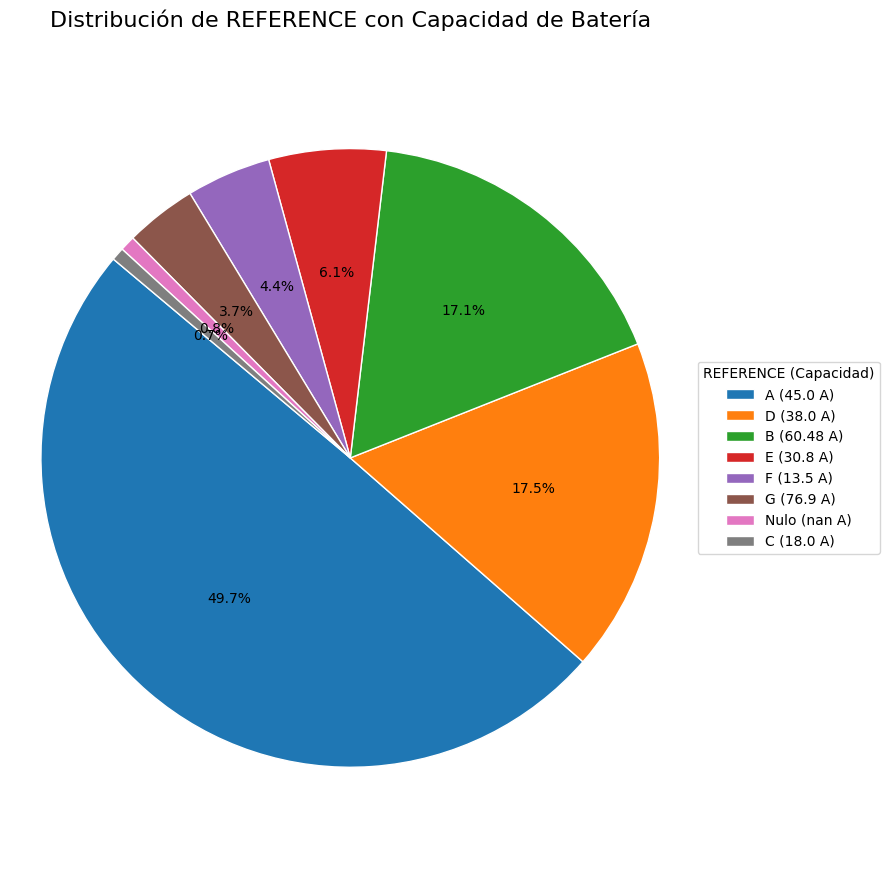

In [33]:
import matplotlib.pyplot as plt

# Copia para trabajar con nulos como texto
Trans_copy = Transacciones.copy()
Trans_copy["REFERENCE"] = Trans_copy["REFERENCE"].fillna("Nulo")

# Conteo de cada REFERENCE (incluyendo nulos)
conteo_reference = Trans_copy["REFERENCE"].value_counts()

# Obtener la BATTERY CAPACITY (A) correspondiente para cada REFERENCE
capacidad_por_ref = Trans_copy.drop_duplicates("REFERENCE").set_index("REFERENCE")["BATTERY CAPACITY (A)"]

# Crear etiquetas para la leyenda: "REFERENCE (X A)"
etiquetas = [
    f"{ref} ({capacidad_por_ref.get(ref, 'N/A')} A)"
    for ref in conteo_reference.index
]

# Crear gráfico de pastel sin etiquetas
plt.figure(figsize=(9, 9))
wedges, texts, autotexts = plt.pie(
    conteo_reference,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Distribución de REFERENCE con Capacidad de Batería", fontsize=16)
plt.axis('equal')

# Añadir leyenda con etiquetas personalizadas
plt.legend(wedges, etiquetas, title="REFERENCE (Capacidad)", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()




In [34]:
Transacciones.head(30)

,ID,RFID,BATTERY CAPACITY (A),REFERENCE,SOCKET,ENERGY (KW),TIME CHARGING (min),TIME NO CHARGING (min),DATE_START SESSION,HOUR_START SESSION,DATE_CHARGING END,HOUR_CHARGING END,DATE_SESSION END,HOUR_SESSION END,Voltage(V)
0,3744061,E2541124,18.00,C,2,8.691,327,0,2024-07-03,07:09:00,2024-07-03,12:36:00,2024-07-03,12:37:00,482.833333
1,3747743,4210747D,45.00,A,1,36.194,343,30,2024-07-04,05:58:00,2024-07-04,11:42:00,2024-07-04,12:12:00,804.311111
2,3766771,52FC1964,76.90,G,1,43.690,445,195,2024-07-09,06:01:00,2024-07-09,13:27:00,2024-07-09,16:42:00,568.140442
3,3794374,4210747D,45.00,A,2,55.929,533,0,2024-07-16,05:59:00,2024-07-16,14:52:00,2024-07-16,14:52:00,1242.866667
4,3796049,E2541124,18.00,C,1,10.488,256,0,2024-07-16,12:33:00,2024-07-16,16:50:00,2024-07-16,16:50:00,582.666667
5,3823280,52FC1964,76.90,G,1,31.306,320,0,2024-07-23,05:57:00,2024-07-23,11:17:00,2024-07-23,11:17:00,407.100130
6,3824562,041E6A8A317780,60.48,B,1,31.593,299,0,2024-07-23,11:23:00,2024-07-23,16:22:00,2024-07-23,16:22:00,522.371032
7,3831236,4210747D,45.00,A,2,52.202,497,98,2024-07-25,06:00:00,2024-07-25,14:18:00,2024-07-25,15:57:00,1160.044444
8,3852548,041E6A8A317780,60.48,B,2,35.296,333,190,2024-07-30,06:35:00,2024-07-30,12:09:00,2024-07-30,15:20:00,583.597884
9,3860203,4210747D,45.00,A,2,47.151,449,143,2024-08-01,06:02:00,2024-08-01,13:32:00,2024-08-01,15:55:00,1047.800000


In [35]:
from IPython.display import display, HTML

# Asegurar formato de fecha
Transacciones['DATE_START SESSION'] = pd.to_datetime(Transacciones['DATE_START SESSION'])

# Crear columna de año-mes
Transacciones['MES'] = Transacciones['DATE_START SESSION'].dt.to_period('M')

# Crear lista de DataFrames por mes
lista_dataframes = []

# Agrupar por mes y contar incluyendo nulos
for mes, grupo in Transacciones.groupby('MES'):
    conteo = grupo['BATTERY CAPACITY (A)'].value_counts(dropna=False).reset_index()
    conteo.columns = ['BATTERY CAPACITY (A)', 'conteo']
    conteo['BATTERY CAPACITY (A)'] = conteo['BATTERY CAPACITY (A)'].fillna('Nulo')  # Opcional para mostrar claramente los nulos
    conteo['MES'] = mes
    lista_dataframes.append((mes, conteo))

# Mostrar cada DataFrame por mes con título bonito
for mes, df_mes in lista_dataframes:
    display(HTML(f"<h3 style='color: steelblue;'>Frecuencia de BATTERY CAPACITY (A) para el mes: {mes}</h3>"))
    display(HTML(df_mes.to_html(index=False)))


BATTERY CAPACITY (A),conteo,MES
45.00,3,2024-07
18.00,2,2024-07
76.90,2,2024-07
60.48,2,2024-07


BATTERY CAPACITY (A),conteo,MES
60.48,6,2024-08
76.90,4,2024-08
45.00,3,2024-08
18.00,3,2024-08


BATTERY CAPACITY (A),conteo,MES
45.00,23,2024-09
60.48,6,2024-09
76.90,5,2024-09


BATTERY CAPACITY (A),conteo,MES
45.0,25,2024-10
76.9,6,2024-10
38.0,6,2024-10
60.48,5,2024-10
30.8,3,2024-10
13.5,3,2024-10
18.0,1,2024-10
Nulo,1,2024-10


BATTERY CAPACITY (A),conteo,MES
45.00,34,2024-11
38.00,24,2024-11
60.48,18,2024-11
76.90,12,2024-11
30.80,8,2024-11
13.50,7,2024-11


BATTERY CAPACITY (A),conteo,MES
45.00,49,2024-12
38.00,24,2024-12
60.48,19,2024-12
30.80,9,2024-12
76.90,4,2024-12
13.50,2,2024-12


BATTERY CAPACITY (A),conteo,MES
45.0,47,2025-01
38.0,24,2025-01
60.48,19,2025-01
13.5,6,2025-01
Nulo,3,2025-01
30.8,3,2025-01


BATTERY CAPACITY (A),conteo,MES
45.00,94,2025-02
38.00,29,2025-02
60.48,21,2025-02
13.50,7,2025-02
30.80,4,2025-02


BATTERY CAPACITY (A),conteo,MES
45.0,101,2025-03
60.48,35,2025-03
38.0,23,2025-03
30.8,14,2025-03
13.5,8,2025-03
Nulo,1,2025-03


BATTERY CAPACITY (A),conteo,MES
45.0,59,2025-04
38.0,24,2025-04
60.48,20,2025-04
30.8,13,2025-04
13.5,6,2025-04
Nulo,2,2025-04


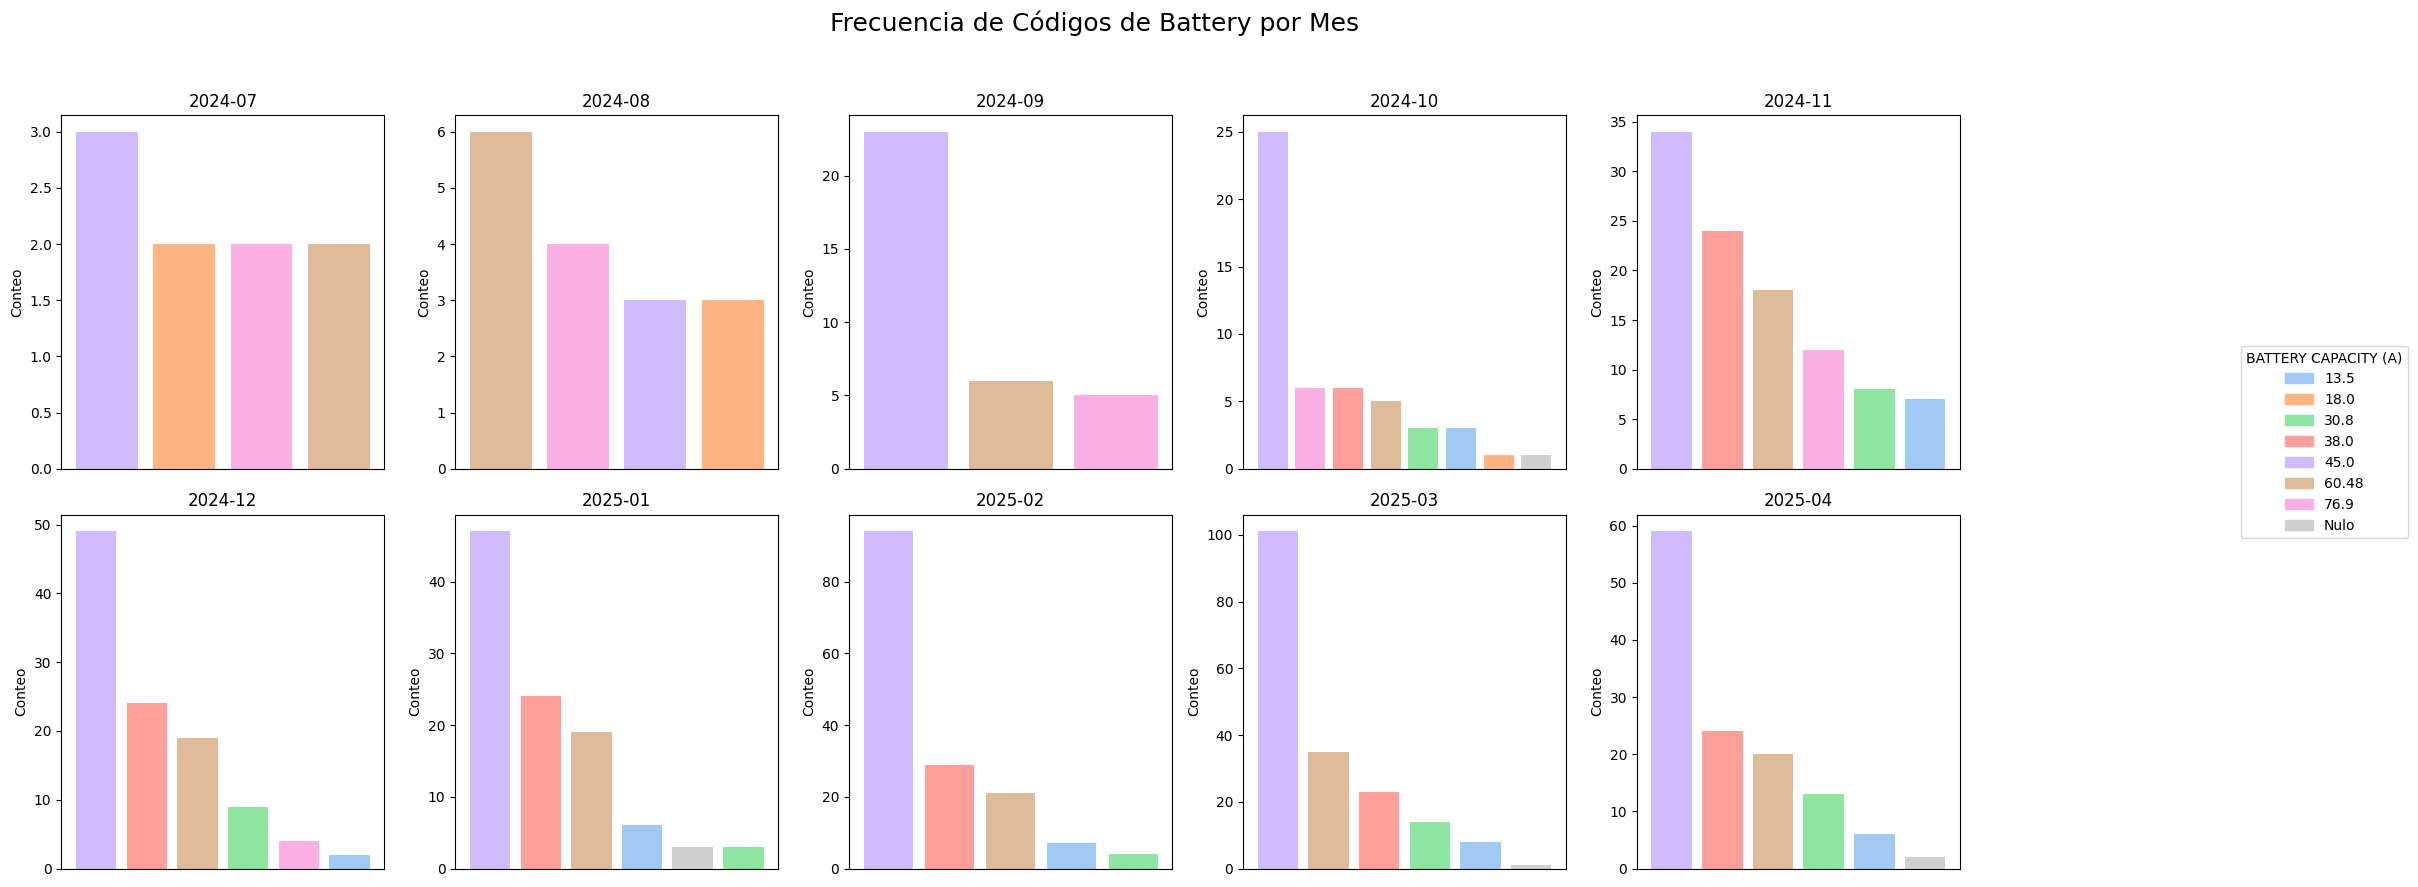

In [36]:
# Crear colores consistentes para cada código (incluyendo nulos como 'Nulo')
todos_codigos = sorted(set(
    str(c) if pd.notnull(c) else 'Nulo'
    for _, df in lista_dataframes
    for c in df['BATTERY CAPACITY (A)']
))
palette = sns.color_palette('pastel', len(todos_codigos))
colores_por_codigo = dict(zip(todos_codigos, palette))

# Crear subplots
total = len(lista_dataframes)
filas, columnas = 2, 5
fig, axs = plt.subplots(filas, columnas, figsize=(22, 9))
fig.suptitle('Frecuencia de Códigos de Battery por Mes', fontsize=18)
axs = axs.flatten()

# Dibujar los gráficos
for i, (mes, df_mes) in enumerate(lista_dataframes):
    ax = axs[i]
    colores = [
        colores_por_codigo[str(cod) if pd.notnull(cod) else 'Nulo']
        for cod in df_mes['BATTERY CAPACITY (A)']
    ]
    bars = ax.bar(range(len(df_mes)), df_mes['conteo'], color=colores)
    ax.set_title(str(mes))
    ax.set_xticks([])  # Sin nombres de códigos en X
    ax.set_xlabel('')
    ax.set_ylabel('Conteo')

# Leyenda general
handles = [plt.Rectangle((0, 0), 1, 1, color=colores_por_codigo[c]) for c in todos_codigos]
labels = [str(c) for c in todos_codigos]
fig.legend(handles, labels, title='BATTERY CAPACITY (A)', loc='center right', bbox_to_anchor=(1.1, 0.5))

# Eliminar subplots vacíos
for j in range(i + 1, filas * columnas):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


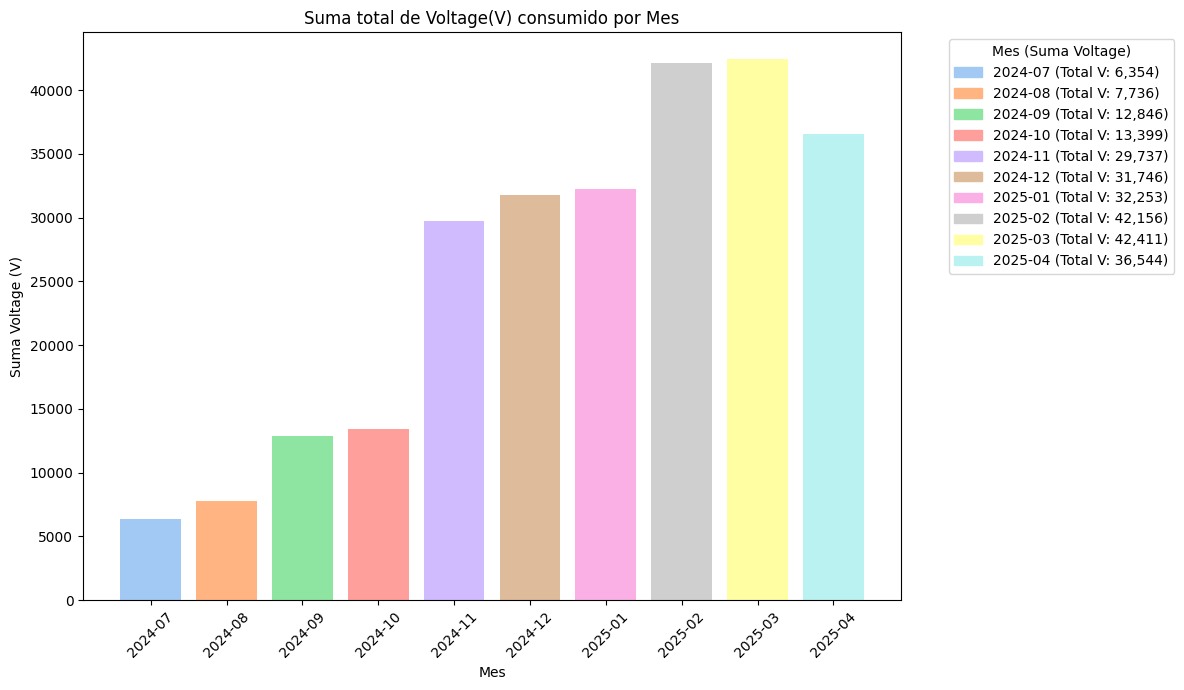

In [37]:
# Calcular suma total de Voltage por mes (incluyendo nulos en Voltage(V) si los hay, se suman como 0)
suma_voltage_por_mes = Transacciones.groupby('MES')['Voltage(V)'].sum(min_count=1).fillna(0)

# Crear un DataFrame para graficar fácilmente
df_plot = suma_voltage_por_mes.reset_index()
df_plot['MES_str'] = df_plot['MES'].astype(str)

# Crear la paleta de colores
palette = sns.color_palette('pastel', len(df_plot))

# Graficar histograma de barras (un solo valor por mes, barras verticales)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(df_plot['MES_str'], df_plot['Voltage(V)'], color=palette)

# Leyenda personalizada con mes y suma total formateada
labels_legend = [f"{mes} (Total V: {voltaje:,.0f})" for mes, voltaje in zip(df_plot['MES_str'], df_plot['Voltage(V)'])]
handles_legend = [plt.Rectangle((0,0),1,1, color=color) for color in palette]

ax.legend(handles_legend, labels_legend, title='Mes (Suma Voltage)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Mes')
ax.set_ylabel('Suma Voltage (V)')
ax.set_title('Suma total de Voltage(V) consumido por Mes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

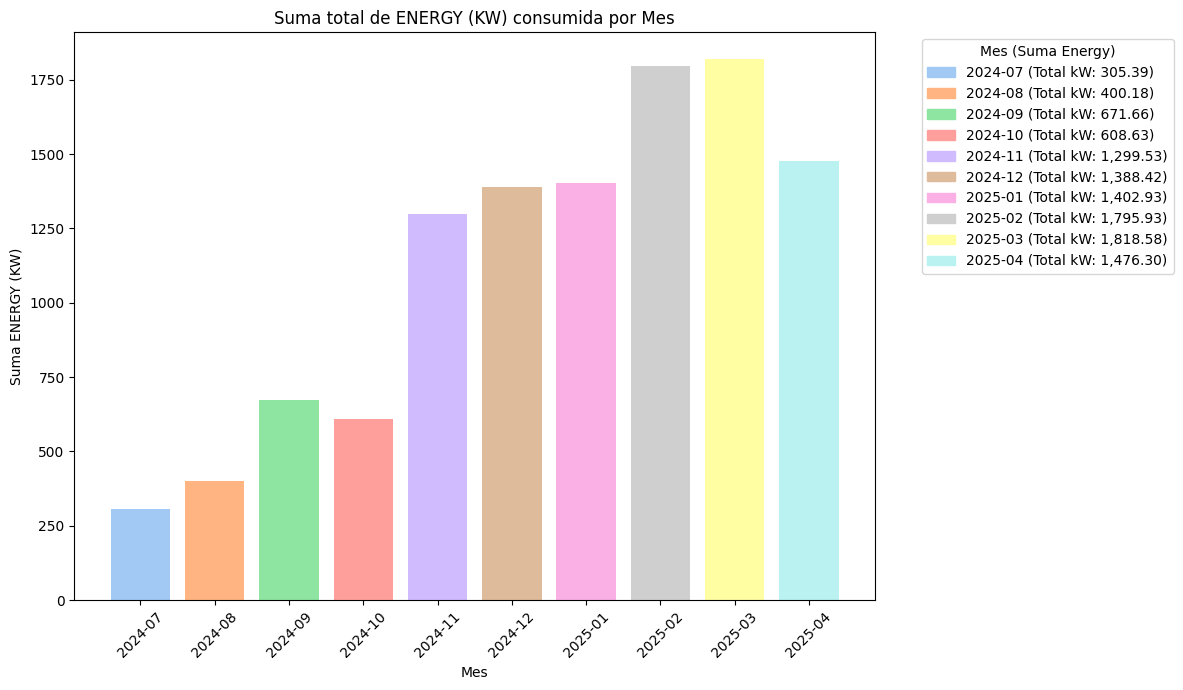

In [38]:
# Sumar la energía consumida por mes (incluyendo nulos)
suma_energia_por_mes = Transacciones.groupby('MES')['ENERGY (KW)'].sum(min_count=1).fillna(0)

# Crear DataFrame para graficar
df_plot_energia = suma_energia_por_mes.reset_index()
df_plot_energia['MES_str'] = df_plot_energia['MES'].astype(str)

# Crear paleta de colores
palette_energia = sns.color_palette('pastel', len(df_plot_energia))

# Graficar barras
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(df_plot_energia['MES_str'], df_plot_energia['ENERGY (KW)'], color=palette_energia)

# Leyenda con mes y suma de energía formateada
labels_legend_energia = [f"{mes} (Total kW: {energia:,.2f})" for mes, energia in zip(df_plot_energia['MES_str'], df_plot_energia['ENERGY (KW)'])]
handles_legend_energia = [plt.Rectangle((0,0),1,1, color=color) for color in palette_energia]

ax.legend(handles_legend_energia, labels_legend_energia, title='Mes (Suma Energy)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Mes')
ax.set_ylabel('Suma ENERGY (KW)')
ax.set_title('Suma total de ENERGY (KW) consumida por Mes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

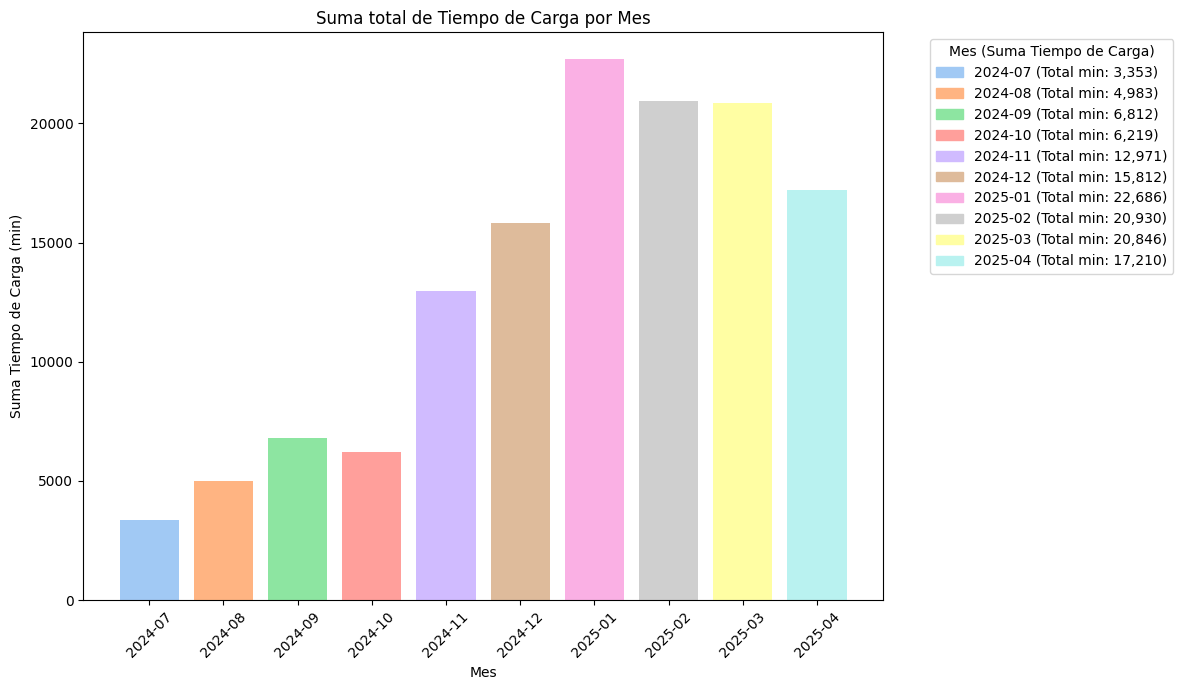

In [39]:
# Sumar el tiempo de carga por mes (incluyendo nulos)
suma_tiempo_por_mes = Transacciones.groupby('MES')['TIME CHARGING (min)'].sum(min_count=1).fillna(0)

# Preparar DataFrame para graficar
df_plot_tiempo = suma_tiempo_por_mes.reset_index()
df_plot_tiempo['MES_str'] = df_plot_tiempo['MES'].astype(str)

# Crear paleta de colores
palette_tiempo = sns.color_palette('pastel', len(df_plot_tiempo))

# Graficar barras
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(df_plot_tiempo['MES_str'], df_plot_tiempo['TIME CHARGING (min)'], color=palette_tiempo)

# Crear leyenda con mes y suma total formateada
labels_legend_tiempo = [f"{mes} (Total min: {tiempo:,.0f})" for mes, tiempo in zip(df_plot_tiempo['MES_str'], df_plot_tiempo['TIME CHARGING (min)'])]
handles_legend_tiempo = [plt.Rectangle((0,0),1,1, color=color) for color in palette_tiempo]

ax.legend(handles_legend_tiempo, labels_legend_tiempo, title='Mes (Suma Tiempo de Carga)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Mes')
ax.set_ylabel('Suma Tiempo de Carga (min)')
ax.set_title('Suma total de Tiempo de Carga por Mes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [40]:
#Archivo Sesiones
Sesiones=dataFrames['Sesiones.csv']
# Verificar si ENERGY es múltiplo de CAPACIDAD
multiplo = (Sesiones['ID'] % Sesiones['Minuto a minuto'] == 0)
# Calcular porcentaje de coincidencias
porcentaje_multiplo = (multiplo.sum() / len(multiplo)) * 100
print(f"✅ Porcentaje de veces que ENERGY es múltiplo exacto de Capacidad: {porcentaje_multiplo:.2f}%")


✅ Porcentaje de veces que ENERGY es múltiplo exacto de Capacidad: 100.00%


In [41]:
#Separacion de fechas
Sesiones['Inicio'] = pd.to_datetime(Sesiones['Inicio'], format='%d/%m/%Y %H:%M', errors='coerce')
Sesiones['Final'] = pd.to_datetime(Sesiones['Final'], format='%d/%m/%Y %H:%M', errors='coerce')
Sesiones['DATE_START'] = Sesiones['Inicio'].dt.date
Sesiones['HOUR_START'] = Sesiones['Inicio'].dt.time
Sesiones['DATE_FINAL'] = Sesiones['Final'].dt.date
Sesiones['HOUR_FINAL'] = Sesiones['Final'].dt.time
Sesiones=Sesiones.drop(["Final","Inicio"], axis=1)
#Eliinacion de coumnas nulas
Sesiones = Sesiones.drop(["costo", "Minuto a minuto"], axis=1)

In [42]:
#Cambiar nombre de columnas
Sesiones.rename(columns={
    'Toma': 'SOCKET',
    'Tarjeta': 'CARD',
    'Duración(mins)':'DURATION (mins)',
    'Energía(kWh)':'ENERGY(KW)'
}, inplace=True)

In [43]:
#Sesiones = Sesiones.iloc[::-1].reset_index(drop=True)
Sesiones.head(30)

,ID,SOCKET,USER ID,CARD,DURATION (mins),Tiempo seleccionado(mins),ENERGY(KW),Energía seleccionada(kWh),Modo,Total(€),Token de pago,Ref Ext 1,Ref Ext 2,DATE_START,HOUR_START,DATE_FINAL,HOUR_FINAL
0,4971580,2,1131724,1EB318F9,16,NaN,0.00,NaN,CARD,0.00,1000097552,NaN,NaN,2025-04-30,16:54:00,2025-04-30,17:10:00
1,4970680,1,1131724,1EB318F9,241,NaN,6.73,10.0,APP,8754.20,---,---,---,2025-04-30,12:39:00,2025-04-30,16:40:00
2,4970627,2,1149591,07C09540,240,NaN,24.44,40.0,APP,31770.70,---,---,---,2025-04-30,12:31:00,2025-04-30,16:31:00
3,4969805,1,1131634,D45E7EAF,84,NaN,6.94,20.0,APP,9015.50,---,---,---,2025-04-30,10:18:00,2025-04-30,11:42:00
4,4969233,2,1265951,73ECE76B,180,180.0,9.36,NaN,APP,12164.10,---,---,---,2025-04-30,08:27:00,2025-04-30,11:27:00
5,4968525,1,1131634,D45E7EAF,240,NaN,22.87,40.0,APP,29732.30,---,---,---,2025-04-30,06:11:00,2025-04-30,10:11:00
6,4965374,1,958228,4210747D,195,NaN,16.51,NaN,OTHER,21459.10,---,NaN,NaN,2025-04-29,13:37:00,2025-04-29,16:52:00
7,4965024,2,1156412,81407EED,228,240.0,18.61,NaN,APP,24644.13,---,---,---,2025-04-29,12:32:00,2025-04-29,16:21:00
8,4964025,1,1135002,9D45BEFB,144,NaN,8.34,60.0,APP,10843.30,---,---,---,2025-04-29,09:37:00,2025-04-29,12:02:00
9,4963399,2,1156412,81407EED,240,240.0,22.29,NaN,APP,28970.50,---,---,---,2025-04-29,07:43:00,2025-04-29,11:43:00


In [44]:
print(Sesiones.shape)
Sesiones = Sesiones[Sesiones['ENERGY(KW)'] != 0]
print(Sesiones.shape)

(931, 17)
(881, 17)


In [45]:
#Archivo Chart
Chart=dataFrames['chart.csv']
Chart.head(10)

,Category,Value
0,jul-24,305
1,ago-24,400
2,sep-24,671
3,oct-24,608
4,nov-24,1299
5,dic-24,1388
6,ene-25,1402
7,feb-25,1795
8,mar-25,1818
9,abr-25,1476


In [46]:
# Archivo Potencia Maxima:
PotenciaMaxima=dataFrames['potencia-mxima-alcanzada.csv']
PotenciaMaxima = PotenciaMaxima.drop(index=range(0, 479))
PotenciaMaxima['DateTime'] = pd.to_datetime(PotenciaMaxima['DateTime'], format='%d/%m/%Y %H:%M', errors='coerce')
PotenciaMaxima['DATE'] = PotenciaMaxima['DateTime'].dt.date
PotenciaMaxima['HOUR'] = PotenciaMaxima['DateTime'].dt.time
PotenciaMaxima=PotenciaMaxima.drop(["DateTime"], axis=1)
PotenciaMaxima.rename(columns={
    'Potencia instantaneaToma 1 (kW)': 'Potencia_instantanea_Toma_1(KW)',
    'Potencia instantanea Toma 2 (kW)': 'Potencia_instantanea_Toma_2(KW)',
}, inplace=True)
print(PotenciaMaxima.shape)
PotenciaMaxima = PotenciaMaxima.drop_duplicates()
PotenciaMaxima['Potencia_instantanea_Toma_1(KW)']=PotenciaMaxima['Potencia_instantanea_Toma_1(KW)'].fillna(0)
PotenciaMaxima['Potencia_instantanea_Toma_2(KW)']=PotenciaMaxima['Potencia_instantanea_Toma_2(KW)'].fillna(0)
print(PotenciaMaxima.shape)



(4311, 4)
(3890, 4)


In [47]:
#DataFrames de Errores por mes
PotenciaMaxima['DATE'] = pd.to_datetime(PotenciaMaxima['DATE'])
# Crear una nueva columna con el año y mes en formato AAAA-MM
PotenciaMaxima['MES'] = PotenciaMaxima['DATE'].dt.to_period('M')
# Crear una lista vacía para almacenar los DataFrames
# Crear la columna con la suma de potencias
PotenciaMaxima['Potencia_total'] = (
    PotenciaMaxima['Potencia_instantanea_Toma_1(KW)'] +
    PotenciaMaxima['Potencia_instantanea_Toma_2(KW)']
)

# Agrupar por mes y sumar la potencia total
suma_potencia_por_mes = (
    PotenciaMaxima.groupby('MES')['Potencia_total']
    .sum()
    .reset_index()
    .rename(columns={'Potencia_total': 'Suma Potencia Total (KW)'})
)

# Mostrar con HTML
from IPython.display import display, HTML

display(HTML("<h2>Suma de Potencia Total por Mes</h2>"))
display(HTML(suma_potencia_por_mes.to_html(index=False)))
PotenciaMaxima=PotenciaMaxima.drop(columns=['Potencia_total'])
PotenciaMaxima=PotenciaMaxima.drop(columns=['MES'])


MES,Suma Potencia Total (KW)
2024-07,348.58
2024-08,501.13
2024-09,836.90
2024-10,815.97
2024-11,1841.41
2024-12,1844.66
2025-01,1907.46
2025-02,2532.78
2025-03,2669.85
2025-04,2023.26


In [48]:
PotenciaMaxima.head()

,Potencia_instantanea_Toma_1(KW),Potencia_instantanea_Toma_2(KW),DATE,HOUR
479,0.0,0.00,2024-07-03,07:09:00
480,0.0,2.83,2024-07-03,08:00:00
481,0.0,2.85,2024-07-03,09:00:00
482,0.0,2.88,2024-07-03,10:00:00
483,0.0,1.61,2024-07-03,11:00:00


In [49]:
# Selección correcta de columnas con una lista
PotenciaMaxima_Socket1 = PotenciaMaxima[["Potencia_instantanea_Toma_1(KW)", "DATE", "HOUR"]].copy()
PotenciaMaxima_Socket2 = PotenciaMaxima[["Potencia_instantanea_Toma_2(KW)", "DATE", "HOUR"]].copy()


In [50]:
PotenciaMaxima_Socket1.head()

,Potencia_instantanea_Toma_1(KW),DATE,HOUR
479,0.0,2024-07-03,07:09:00
480,0.0,2024-07-03,08:00:00
481,0.0,2024-07-03,09:00:00
482,0.0,2024-07-03,10:00:00
483,0.0,2024-07-03,11:00:00


In [51]:
PotenciaMaxima_Socket2.head()

,Potencia_instantanea_Toma_2(KW),DATE,HOUR
479,0.00,2024-07-03,07:09:00
480,2.83,2024-07-03,08:00:00
481,2.85,2024-07-03,09:00:00
482,2.88,2024-07-03,10:00:00
483,1.61,2024-07-03,11:00:00


In [52]:
Transacciones.head()

,ID,RFID,BATTERY CAPACITY (A),REFERENCE,SOCKET,ENERGY (KW),TIME CHARGING (min),TIME NO CHARGING (min),DATE_START SESSION,HOUR_START SESSION,DATE_CHARGING END,HOUR_CHARGING END,DATE_SESSION END,HOUR_SESSION END,Voltage(V),MES
0,3744061,E2541124,18.0,C,2,8.691,327,0,2024-07-03,07:09:00,2024-07-03,12:36:00,2024-07-03,12:37:00,482.833333,2024-07
1,3747743,4210747D,45.0,A,1,36.194,343,30,2024-07-04,05:58:00,2024-07-04,11:42:00,2024-07-04,12:12:00,804.311111,2024-07
2,3766771,52FC1964,76.9,G,1,43.690,445,195,2024-07-09,06:01:00,2024-07-09,13:27:00,2024-07-09,16:42:00,568.140442,2024-07
3,3794374,4210747D,45.0,A,2,55.929,533,0,2024-07-16,05:59:00,2024-07-16,14:52:00,2024-07-16,14:52:00,1242.866667,2024-07
4,3796049,E2541124,18.0,C,1,10.488,256,0,2024-07-16,12:33:00,2024-07-16,16:50:00,2024-07-16,16:50:00,582.666667,2024-07


In [53]:
# Crear columnas binarias para cada tipo de socket
Transacciones['SOCKET_1'] = (Transacciones['SOCKET'] == 1).astype(int)
Transacciones['SOCKET_2'] = (Transacciones['SOCKET'] == 2).astype(int)

# Columnas a conservar
columnas_deseadas = [
    'RFID',
    'REFERENCE',
    'BATTERY CAPACITY (A)',
    'DATE_START SESSION',
    'HOUR_START SESSION',
    'DATE_SESSION END',
    'HOUR_SESSION END',

]

# Crear DataFrame solo con SOCKET_1 == 1
Transacciones_SOCKET1 = Transacciones[Transacciones['SOCKET_1'] == 1][columnas_deseadas].copy()

# Crear DataFrame solo con SOCKET_2 == 1
Transacciones_SOCKET2 = Transacciones[Transacciones['SOCKET_2'] == 1][columnas_deseadas].copy()

In [54]:
Transacciones_SOCKET1.head()

,RFID,REFERENCE,BATTERY CAPACITY (A),DATE_START SESSION,HOUR_START SESSION,DATE_SESSION END,HOUR_SESSION END
1,4210747D,A,45.00,2024-07-04,05:58:00,2024-07-04,12:12:00
2,52FC1964,G,76.90,2024-07-09,06:01:00,2024-07-09,16:42:00
4,E2541124,C,18.00,2024-07-16,12:33:00,2024-07-16,16:50:00
5,52FC1964,G,76.90,2024-07-23,05:57:00,2024-07-23,11:17:00
6,041E6A8A317780,B,60.48,2024-07-23,11:23:00,2024-07-23,16:22:00


In [55]:
Transacciones_SOCKET2.head()

,RFID,REFERENCE,BATTERY CAPACITY (A),DATE_START SESSION,HOUR_START SESSION,DATE_SESSION END,HOUR_SESSION END
0,E2541124,C,18.00,2024-07-03,07:09:00,2024-07-03,12:37:00
3,4210747D,A,45.00,2024-07-16,05:59:00,2024-07-16,14:52:00
7,4210747D,A,45.00,2024-07-25,06:00:00,2024-07-25,15:57:00
8,041E6A8A317780,B,60.48,2024-07-30,06:35:00,2024-07-30,15:20:00
9,4210747D,A,45.00,2024-08-01,06:02:00,2024-08-01,15:55:00


In [56]:
precio_medio=np.median(Sesiones["Total(€)"]/Sesiones["ENERGY(KW)"])
print(np.median(Sesiones["Total(€)"]/Sesiones["ENERGY(KW)"]))

1299.8866608544029


In [57]:
# Asegurar que las columnas sean string antes de concatenar
PotenciaMaxima_Socket1['DATE'] = PotenciaMaxima_Socket1['DATE'].astype(str)
PotenciaMaxima_Socket1['HOUR'] = PotenciaMaxima_Socket1['HOUR'].astype(str)

Transacciones_SOCKET1['DATE_START SESSION'] = Transacciones_SOCKET1['DATE_START SESSION'].astype(str)
Transacciones_SOCKET1['HOUR_START SESSION'] = Transacciones_SOCKET1['HOUR_START SESSION'].astype(str)
Transacciones_SOCKET1['DATE_SESSION END'] = Transacciones_SOCKET1['DATE_SESSION END'].astype(str)
Transacciones_SOCKET1['HOUR_SESSION END'] = Transacciones_SOCKET1['HOUR_SESSION END'].astype(str)

# Crear columnas de datetime combinando fecha y hora
PotenciaMaxima_Socket1['DATETIME'] = pd.to_datetime(PotenciaMaxima_Socket1['DATE'] + ' ' + PotenciaMaxima_Socket1['HOUR'])
Transacciones_SOCKET1['DATETIME_INICIO'] = pd.to_datetime(Transacciones_SOCKET1['DATE_START SESSION'] + ' ' + Transacciones_SOCKET1['HOUR_START SESSION'])
Transacciones_SOCKET1['DATETIME_FIN'] = pd.to_datetime(Transacciones_SOCKET1['DATE_SESSION END'] + ' ' + Transacciones_SOCKET1['HOUR_SESSION END'])

# Inicializar columnas nuevas
PotenciaMaxima_Socket1['REFERENCE'] = 0
PotenciaMaxima_Socket1['BATTERY CAPACITY (A)'] = 0

# Asignar valores donde DATETIME esté en el rango de inicio y fin
for _, row in Transacciones_SOCKET1.iterrows():
    mask = (PotenciaMaxima_Socket1['DATETIME'] >= row['DATETIME_INICIO']) & (PotenciaMaxima_Socket1['DATETIME'] <= row['DATETIME_FIN'])
    PotenciaMaxima_Socket1.loc[mask, 'REFERENCE'] = row['REFERENCE']
    PotenciaMaxima_Socket1.loc[mask, 'BATTERY CAPACITY (A)'] = row['BATTERY CAPACITY (A)']



<ipython-input-57-cd57cb73198d>:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  PotenciaMaxima_Socket1.loc[mask, 'REFERENCE'] = row['REFERENCE']
<ipython-input-57-cd57cb73198d>:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '76.9' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  PotenciaMaxima_Socket1.loc[mask, 'BATTERY CAPACITY (A)'] = row['BATTERY CAPACITY (A)']


In [58]:
# Asegurar que las columnas sean string antes de concatenar
PotenciaMaxima_Socket2['DATE'] = PotenciaMaxima_Socket2['DATE'].astype(str)
PotenciaMaxima_Socket2['HOUR'] = PotenciaMaxima_Socket2['HOUR'].astype(str)

Transacciones_SOCKET2['DATE_START SESSION'] = Transacciones_SOCKET2['DATE_START SESSION'].astype(str)
Transacciones_SOCKET2['HOUR_START SESSION'] = Transacciones_SOCKET2['HOUR_START SESSION'].astype(str)
Transacciones_SOCKET2['DATE_SESSION END'] = Transacciones_SOCKET2['DATE_SESSION END'].astype(str)
Transacciones_SOCKET2['HOUR_SESSION END'] = Transacciones_SOCKET2['HOUR_SESSION END'].astype(str)

# Crear columnas de datetime combinando fecha y hora
PotenciaMaxima_Socket2['DATETIME'] = pd.to_datetime(PotenciaMaxima_Socket2['DATE'] + ' ' + PotenciaMaxima_Socket2['HOUR'])
Transacciones_SOCKET2['DATETIME_INICIO'] = pd.to_datetime(Transacciones_SOCKET2['DATE_START SESSION'] + ' ' + Transacciones_SOCKET2['HOUR_START SESSION'])
Transacciones_SOCKET2['DATETIME_FIN'] = pd.to_datetime(Transacciones_SOCKET2['DATE_SESSION END'] + ' ' + Transacciones_SOCKET2['HOUR_SESSION END'])

# Inicializar columnas nuevas
PotenciaMaxima_Socket2['REFERENCE'] = 0
PotenciaMaxima_Socket2['BATTERY CAPACITY (A)'] = 0

# Asignar valores donde DATETIME esté en el rango de inicio y fin
for _, row in Transacciones_SOCKET2.iterrows():
    mask = (PotenciaMaxima_Socket2['DATETIME'] >= row['DATETIME_INICIO']) & (PotenciaMaxima_Socket2['DATETIME'] <= row['DATETIME_FIN'])
    PotenciaMaxima_Socket2.loc[mask, 'REFERENCE'] = row['REFERENCE']
    PotenciaMaxima_Socket2.loc[mask, 'BATTERY CAPACITY (A)'] = row['BATTERY CAPACITY (A)']

<ipython-input-58-fe259f6bdc5b>:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'C' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  PotenciaMaxima_Socket2.loc[mask, 'REFERENCE'] = row['REFERENCE']
<ipython-input-58-fe259f6bdc5b>:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '60.48' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  PotenciaMaxima_Socket2.loc[mask, 'BATTERY CAPACITY (A)'] = row['BATTERY CAPACITY (A)']


In [59]:
print("Ejemplo en PotenciaMaxima_Socket1:")
print(PotenciaMaxima_Socket1[['DATETIME']].head())

print("\nEjemplo en Transacciones_SOCKET1:")
print(Transacciones_SOCKET2[['DATETIME_INICIO', 'DATETIME_FIN']].head())

Ejemplo en PotenciaMaxima_Socket1:
               DATETIME
479 2024-07-03 07:09:00
480 2024-07-03 08:00:00
481 2024-07-03 09:00:00
482 2024-07-03 10:00:00
483 2024-07-03 11:00:00

Ejemplo en Transacciones_SOCKET1:
      DATETIME_INICIO        DATETIME_FIN
0 2024-07-03 07:09:00 2024-07-03 12:37:00
3 2024-07-16 05:59:00 2024-07-16 14:52:00
7 2024-07-25 06:00:00 2024-07-25 15:57:00
8 2024-07-30 06:35:00 2024-07-30 15:20:00
9 2024-08-01 06:02:00 2024-08-01 15:55:00


In [60]:
PotenciaMaxima_Socket1["Voltage(V)"] = np.where(
    (PotenciaMaxima_Socket1["BATTERY CAPACITY (A)"].notna()) & (PotenciaMaxima_Socket1["BATTERY CAPACITY (A)"] != 0),
    (PotenciaMaxima_Socket1["Potencia_instantanea_Toma_1(KW)"] * 1000) / PotenciaMaxima_Socket1["BATTERY CAPACITY (A)"],
    np.nan  # O podrías usar 0 o algún otro valor por defecto
)
PotenciaMaxima_Socket1["Voltage(V)"] = PotenciaMaxima_Socket1["Voltage(V)"].fillna(0)
PotenciaMaxima_Socket1.head(20)
PotenciaMaxima_Socket1.to_csv('PotenciaMaxima_Socket1.csv', index=False)

In [61]:
PotenciaMaxima_Socket2["Voltage(V)"] = np.where(
    (PotenciaMaxima_Socket2["BATTERY CAPACITY (A)"].notna()) & (PotenciaMaxima_Socket2["BATTERY CAPACITY (A)"] != 0),
    (PotenciaMaxima_Socket2["Potencia_instantanea_Toma_2(KW)"] * 1000) / PotenciaMaxima_Socket2["BATTERY CAPACITY (A)"],
    np.nan  # O podrías usar 0 o algún otro valor por defecto
)
PotenciaMaxima_Socket2["Voltage(V)"] = PotenciaMaxima_Socket2["Voltage(V)"].fillna(0)
PotenciaMaxima_Socket2.head(20)
PotenciaMaxima_Socket2.to_csv('PotenciaMaxima_Socket2.csv', index=False)

In [62]:
#transacciones
Transacciones.to_csv('Transacciones.csv', index=False)

In [63]:
# Agrupar por día y calcular los valores solicitados
resumen_diario = Transacciones.groupby('DATE_START SESSION').agg({
    'RFID': 'nunique',
    'REFERENCE': 'nunique',
    'ENERGY (KW)': 'sum',
    'Voltage(V)': 'sum',
    'TIME CHARGING (min)': 'sum'
}).reset_index()

# Renombrar columnas para mayor claridad
resumen_diario.columns = ['DIA', 'Cantidad_RFID', 'Cantidad_REFERENCE', 'Suma_ENERGY_KW', 'Suma_Voltage_V',"Tiempo_Carga_min"]
# Mostrar el DataFrame completo
display(resumen_diario)
resumen_diario.to_csv('resumen_diario.csv', index=False)
resumen_diario["Precio"]=resumen_diario["Suma_ENERGY_KW"]*precio_medio
# Mostrar el DataFrame completo
display(resumen_diario)
resumen_diario.to_csv('resumen_diario.csv', index=False)

,DIA,Cantidad_RFID,Cantidad_REFERENCE,Suma_ENERGY_KW,Suma_Voltage_V,Tiempo_Carga_min
0,2024-07-03,1,1,8.691,482.833333,327
1,2024-07-04,1,1,36.194,804.311111,343
2,2024-07-09,1,1,43.690,568.140442,445
3,2024-07-16,2,2,66.417,1825.533333,789
4,2024-07-23,2,2,62.899,929.471162,619
...,...,...,...,...,...,...
170,2025-04-25,4,2,114.273,3172.358510,1327
171,2025-04-26,1,1,5.068,112.622222,47
172,2025-04-28,5,3,103.160,2310.084019,1223
173,2025-04-29,3,2,85.776,1744.752513,1012


,DIA,Cantidad_RFID,Cantidad_REFERENCE,Suma_ENERGY_KW,Suma_Voltage_V,Tiempo_Carga_min,Precio
0,2024-07-03,1,1,8.691,482.833333,327,11297.314969
1,2024-07-04,1,1,36.194,804.311111,343,47048.097803
2,2024-07-09,1,1,43.690,568.140442,445,56792.048213
3,2024-07-16,2,2,66.417,1825.533333,789,86334.572354
4,2024-07-23,2,2,62.899,929.471162,619,81761.571081
...,...,...,...,...,...,...,...
170,2025-04-25,4,2,114.273,3172.358510,1327,148541.948396
171,2025-04-26,1,1,5.068,112.622222,47,6587.825597
172,2025-04-28,5,3,103.160,2310.084019,1223,134096.307934
173,2025-04-29,3,2,85.776,1744.752513,1012,111499.078221


In [64]:

# Unir los DataFrames por DATE y HOUR
df_comb = pd.merge(
    PotenciaMaxima_Socket1,
    PotenciaMaxima_Socket2,
    on=['DATE', 'HOUR'],
    suffixes=('_1', '_2')
)

# Crear nuevas columnas sumadas
df_comb['Potencia_total_KW'] = (
    df_comb['Potencia_instantanea_Toma_1(KW)'] + df_comb['Potencia_instantanea_Toma_2(KW)']
)

df_comb['Battery_Capacity_total_A'] = (
    df_comb['BATTERY CAPACITY (A)_1'].fillna(0) + df_comb['BATTERY CAPACITY (A)_2'].fillna(0)
)

df_comb['Voltage_total_V'] = (
    df_comb['Voltage(V)_1'].fillna(0) + df_comb['Voltage(V)_2'].fillna(0)
)

# Crear un nuevo DataFrame con columnas relevantes
df_sumado = df_comb[['DATE', 'HOUR', 'Potencia_total_KW', 'Battery_Capacity_total_A', 'Voltage_total_V']]

# Mostrar el resultado
df_sumado.head(40)
df_sumado.to_csv('PotenciaMaxima_Pila.csv', index=False)

In [65]:
PotenciaMaxima_Socket1.head(40)

,Potencia_instantanea_Toma_1(KW),DATE,HOUR,DATETIME,REFERENCE,BATTERY CAPACITY (A),Voltage(V)
479,0.00,2024-07-03,07:09:00,2024-07-03 07:09:00,0,0.0,0.000000
480,0.00,2024-07-03,08:00:00,2024-07-03 08:00:00,0,0.0,0.000000
481,0.00,2024-07-03,09:00:00,2024-07-03 09:00:00,0,0.0,0.000000
482,0.00,2024-07-03,10:00:00,2024-07-03 10:00:00,0,0.0,0.000000
483,0.00,2024-07-03,11:00:00,2024-07-03 11:00:00,0,0.0,0.000000
484,0.00,2024-07-03,12:00:00,2024-07-03 12:00:00,0,0.0,0.000000
485,0.00,2024-07-03,12:37:00,2024-07-03 12:37:00,0,0.0,0.000000
487,0.00,2024-07-04,05:58:00,2024-07-04 05:58:00,A,45.0,0.000000
488,6.56,2024-07-04,06:00:00,2024-07-04 06:00:00,A,45.0,145.777778
489,6.56,2024-07-04,07:00:00,2024-07-04 07:00:00,A,45.0,145.777778


In [66]:
PotenciaMaxima_Socket2.head(40)

,Potencia_instantanea_Toma_2(KW),DATE,HOUR,DATETIME,REFERENCE,BATTERY CAPACITY (A),Voltage(V)
479,0.00,2024-07-03,07:09:00,2024-07-03 07:09:00,C,18.0,0.000000
480,2.83,2024-07-03,08:00:00,2024-07-03 08:00:00,C,18.0,157.222222
481,2.85,2024-07-03,09:00:00,2024-07-03 09:00:00,C,18.0,158.333333
482,2.88,2024-07-03,10:00:00,2024-07-03 10:00:00,C,18.0,160.000000
483,1.61,2024-07-03,11:00:00,2024-07-03 11:00:00,C,18.0,89.444444
484,1.18,2024-07-03,12:00:00,2024-07-03 12:00:00,C,18.0,65.555556
485,0.00,2024-07-03,12:37:00,2024-07-03 12:37:00,C,18.0,0.000000
487,0.00,2024-07-04,05:58:00,2024-07-04 05:58:00,0,0.0,0.000000
488,0.00,2024-07-04,06:00:00,2024-07-04 06:00:00,0,0.0,0.000000
489,0.00,2024-07-04,07:00:00,2024-07-04 07:00:00,0,0.0,0.000000
